# Определение популярности геолокации для размещения банкомата (на примере Москвы)

**Цель проекта** — подготовить данные для анализа факторов популярности расположения банкоматов и построить ML-модель, которая сможет предсказывать перспективные точки для их установки.  

В этом ноутбуке:  
- Загружаем и приводим к нужному формату геоданные (ATM, POI);  
- Строим сетку точек-кандидатов;  
- Формируем признаки по близости к POI;  
- Подготавливаем данные к этапу ML-моделирования;  
- Обучаем несколько моделей (Logistic Regression, Decision Tree, Random Forest, CatBoost) и сравниваем их по ключевым метрикам;  
- Определяем наиболее значимые факторы и даём ответ на бизнес-вопрос: какие признаки влияют на успешность точки установки банкомата.  


**Итоги проекта:**

- Подготовлен датасет для анализа: **12 585 точек** с **12 признаками** инфраструктуры  
- Баланс классов: **14,2%** — с банкоматами, **85,8%** — без банкоматов  
- Протестированы 4 модели машинного обучения  
- Ключевые факторы успеха: **плотность объектов инфраструктуры**, **близость к аптекам** и **остановкам**  
- **CatBoost** — лучший для поиска перспективных точек (Recall = 0.75)  
- **Random Forest** — самый точный для точечных рекомендаций (Precision = 0.61)  
- Все модели показали высокое качество (ROC-AUC > 0.83)  
- Решение готово для применения в бизнесе


## Использование библиотеки OSMnx

Для получения геоданных используем библиотеку **OSMnx**.  
Она работает поверх открытой картографической базы **OpenStreetMap (OSM)** и упрощает доступ к данным: зданиям, дорогам, точкам интереса (POI).  

- OpenStreetMap хранит объекты в виде **тегов** (`amenity=atm`, `shop=supermarket`, `highway=bus_stop` и т.д.).  
- OSMnx строит запросы к серверу OSM (Overpass API) и возвращает данные в формате **GeoDataFrame** (таблица + геометрия).  
- Эти данные можно сразу анализировать или сохранять в файлы (`.geojson`, `.csv`).  

В проекте:  
1. Определяем территорию (`place="Moscow, Russia"`).  
2. Указываем нужные теги (например, `amenity=atm` для банкоматов).  
3. Получаем таблицу с координатами и атрибутами объектов.  
4. Сохраняем её в `data/raw/`, чтобы работать дальше без повторных запросов.

Данные
- Источники:
  - Банкоматы (ATM): OpenStreetMap /  GeoJSON (файл: `data/raw/atm_moscow.geojson`).
  - Точки интереса (POI): OpenStreetMap / GeoJSON (файл: `data/raw/poi_moscow.geojson`).
  - Граница города: OSMnx / административные границы.

Таким образом, OSMnx позволяет автоматизировать сбор пространственных данных и использовать их для анализа и построения признаков в ML-модели.


In [113]:
# !pip install osmnx geopandas
import osmnx as ox
import geopandas as gpd

# проверка установки
print("OSMnx:", ox.__version__)
print("GeoPandas:", gpd.__version__)

OSMnx: 2.0.6
GeoPandas: 1.1.1


# Сбор данных

Первый шаг: подгружаем пространственные данные из внешних источников:

- **Банкоматы (ATM)** —  данные по банкоматам в `atm_moscow.geojson`;
- **Точки интереса (POI)** —  данные по точкам интереса в файл `poi_moscow.geojson`, включающий кафе, магазины, аптеки, остановки и другие объекты, полученные из OpenStreetMap.

Все данные переводятся в единую метрическую проекцию EPSG:3857 для дальнейшей работы с расстояниями.

На выходе получаем:
- `atm` — таблицу точек с координатами банкоматов;
- `poi` — таблицу точек с категорией объектов;


## Сбор данных о банкоматах Москвы

На этом шаге выгружаем из OpenStreetMap все объекты с тегом `amenity=atm`.  
Эти точки будут использоваться как целевые объекты анализа — именно для них будем искать факторы популярности.  

Полученные данные:  
- содержат координаты (`geometry`);  
- включают дополнительные атрибуты (например, оператор сети, наличие функции приёма наличных);  
- сохраняются в папку `data/raw/` в формате GeoJSON, чтобы далее использовать их без повторных запросов к API.  

Таким образом, формируем исходный слой данных для последующей очистки и построения признаков.


Выбираем данные

In [114]:
# Определяем регион
place = "Moscow, Russia"

# Указываем нужный тег (банкоматы)
tags = {"amenity": "atm"}

# Загружаем данные из OpenStreetMap
gdf_atm = ox.features_from_place(place, tags).to_crs(3857)

# Проверяем размерность и первые строки
print("Размер набора данных:", gdf_atm.shape)
gdf_atm.head()


Размер набора данных: (2059, 91)


geometry amenity  \
element id                                                   
node    408385048  POINT (4196915.311 7510726.416)     atm   
        432502063  POINT (4185805.169 7514516.401)     atm   
        444776906  POINT (4177131.132 7519551.711)     atm   
        444776911  POINT (4166893.201 7530062.632)     atm   
        444776938  POINT (4174947.512 7507443.094)     atm   

                                                       contact:phone  \
element id                                                             
node    408385048                                     +7 800 5555550   
        432502063                                     +7 800 1002424   
        444776906                                                NaN   
        444776911  +7 495 7774888;+7 495 7974242;+7 800 1004888;+...   
        444776938                                                NaN   

                            contact:website                         operator  \
element id                                                                     
node    408385048  https://www.sberbank.ru/                     ПАО Сбербанк   
        432502063       https://www.vtb.ru/                   Банк ВТБ (ПАО)   
        444776906       https://alfabank.ru                       Альфа-Банк   
        444776911           https://mkb.ru/  ПАО "МОСКОВСКИЙ КРЕДИТНЫЙ БАНК"   
        444776938       https://alfabank.ru                  АО "Альфа-Банк"   

                        brand covered drive_through      opening_hours  \
element id                                                               
node    408385048    Сбербанк     NaN           NaN               24/7   
        432502063         ВТБ     NaN           NaN                NaN   
        444776906  Альфа-Банк     NaN           NaN                NaN   
        444776911         NaN     NaN           NaN  Mo-Su 09:00-23:00   
        444776938  Альфа-Банк     NaN           NaN                NaN   

                  wheelchair  ... currency:XBT  bic currency:ETH  \
element id                    ...                                  
node    408385048        NaN  ...          NaN  NaN          NaN   
        432502063        NaN  ...          NaN  NaN          NaN   
        444776906        NaN  ...          NaN  NaN          NaN   
        444776911        NaN  ...          NaN  NaN          NaN   
        444776938        yes  ...          NaN  NaN          NaN   

                  currency:USDT image payment:cash payment:onchain  url  \
element id                                                                
node    408385048           NaN   NaN          NaN             NaN  NaN   
        432502063           NaN   NaN          NaN             NaN  NaN   
        444776906           NaN   NaN          NaN             NaN  NaN   
        444776911           NaN   NaN          NaN             NaN  NaN   
        444776938           NaN   NaN          NaN             NaN  NaN   

                  wikipedia survey:date  
element id                               
node    408385048       NaN         NaN  
        432502063       NaN         NaN  
        444776906       NaN         NaN  
        444776911       NaN         NaN  
        444776938       NaN         NaN  

[5 rows x 91 columns]

Сохраняем результат в папку `data/raw/` в формате GeoJSON.  



In [115]:
# import os

# # Путь к файлу
# output_path = "../data/raw/poi_moscow.geojson"

# # Сохраняем в GeoJSON
# gdf_atm.to_file(output_path, driver="GeoJSON")
# print(f"Файл сохранён: {os.path.abspath(output_path)}")
# print(f"Размер файла: {os.path.getsize(output_path)/(1024*1024):.2f} МБ")


In [116]:
#  Далее будем использовать ссылку с гитхаб для удобства пользования ноутбуком


## Сбор точек интереса (POI)

Для анализа популярности геолокаций выгружаем объекты, которые могут влиять на трафик:
- магазины и супермаркеты (`shop=supermarket`, `shop=convenience`);
- кафе и рестораны (`amenity=cafe`, `amenity=restaurant`);
- аптеки (`amenity=pharmacy`);
- остановки общественного транспорта (`highway=bus_stop`).

Эти данные будут использоваться для построения признаков в модели.


In [117]:
import osmnx as ox

# Определяем регион
place = "Moscow, Russia"

# Теги для выборки POI
tags = {
    "shop": ["supermarket", "convenience"],
    "amenity": ["cafe", "restaurant", "pharmacy"],
    "highway": "bus_stop",
    "railway": "subway_entrance",  # входы в метро
}

# Загружаем все объекты по тегам
gdf_poi = ox.features_from_place(place, tags).to_crs(3857)

print("Размер набора данных:", gdf_poi.shape)
gdf_poi.head()


Размер набора данных: (33848, 409)


geometry bench  bus highway  \
element id                                                             
node    1000      POINT (4141923.505 7557443.192)   NaN  NaN     NaN   
        59629973  POINT (4200705.495 7521508.532)   NaN  NaN     NaN   
        59630005  POINT (4200412.123 7521750.084)   NaN  NaN     NaN   
        59630257  POINT (4200317.691 7521682.999)   NaN  NaN     NaN   
        59631058  POINT (4194463.377 7516572.248)   NaN  NaN     NaN   

                       name public_transport shelter  bin         shop  \
element id                                                               
node    1000      Десяточка              NaN     NaN  NaN  supermarket   
        59629973        NaN              NaN     NaN  NaN          NaN   
        59630005        NaN              NaN     NaN  NaN          NaN   
        59630257        NaN              NaN     NaN  NaN          NaN   
        59631058        NaN              NaN     NaN  NaN          NaN   

                 amenity  ... diet:plant-based stars building:min_level  \
element id                ...                                             
node    1000         NaN  ...              NaN   NaN                NaN   
        59629973     NaN  ...              NaN   NaN                NaN   
        59630005     NaN  ...              NaN   NaN                NaN   
        59630257     NaN  ...              NaN   NaN                NaN   
        59631058     NaN  ...              NaN   NaN                NaN   

                 drink:sparkling_wine drink:wine library weather_protection  \
element id                                                                    
node    1000                      NaN        NaN     NaN                NaN   
        59629973                  NaN        NaN     NaN                NaN   
        59630005                  NaN        NaN     NaN                NaN   
        59630257                  NaN        NaN     NaN                NaN   
        59631058                  NaN        NaN     NaN                NaN   

                 type mapillary landuse  
element id                               
node    1000      NaN       NaN     NaN  
        59629973  NaN       NaN     NaN  
        59630005  NaN       NaN     NaN  
        59630257  NaN       NaN     NaN  
        59631058  NaN       NaN     NaN  

[5 rows x 409 columns]

Сырые данные сохраняем в папку `data/raw`.  
Этот набор используется как базовый источник для дальнейшей очистки и построения признаков.  
  
Дополнительно для передачи сохранён архив с полной выгрузкой.



In [118]:
import os
print("Текущая рабочая директория:", os.getcwd())

Текущая рабочая директория: C:\Users\agurskiy\Yandex.Disk\Git_hub\final-project-atm-analysis\notebooks


In [119]:
# # Сохраняем выгрузку
# raw_path = "../data/raw/poi_moscow.geojson"
# gdf_poi.to_file(raw_path, driver="GeoJSON")

# print(f"Файл сохранён: {os.path.abspath(raw_path)}")
# print(f"Размер файла: {os.path.getsize(raw_path)/(1024*1024):.2f} МБ")


In [120]:
# # # Сохраняем выгрузку по частям
# import os
# raw_path = "../data/raw/poi_moscow.geojson"
# gdf_poi.to_file(raw_path, driver="GeoJSON")

# # Делим на части (Ограничение GitHub)
# file_size_mb = os.path.getsize(raw_path)/(1024*1024)
# print(f"Размер файла: {file_size_mb:.2f} МБ")

# if file_size_mb > 99:
#     num_parts = int(file_size_mb // 99) + 1
#     gdf = gpd.read_file(raw_path)
    
#     for i in range(num_parts):
#         part_gdf = gdf.iloc[i::num_parts]
#         part_path = f"../data/raw/poi_moscow_part{i+1}.geojson"
#         part_gdf.to_file(part_path, driver="GeoJSON")
#         print(f"Часть {i+1} сохранена: {part_path}")

# Подготовка данных

На этом этапе приводим загруженные сырые данные к удобному для анализа виду:

1. Первичная оценка данных:
   - просмотр структуры таблиц (ATM, POI);
   - проверка координат и проекции.

2. Очистка данных:
   - удаление дубликатов и пустых значений;
   - выбор только необходимых атрибутов (amenity, shop, highway и т.д.);
   - сохранение промежуточных файлов.

3. Приведение к единой системе координат (EPSG:3857) для корректных пространственных операций.


**Загружаем исходные геоданные:**  

- ATM — сырые данные о банкоматах;  
- POI — сырые данные о точках интереса (разбиты на три части, объединяем в один набор)

In [121]:
# import geopandas as gpd
# import pandas as pd 
# import warnings # скрытие предупреждений pandas

# # Игнорируем предупреждения pandas
# warnings.filterwarnings("ignore", category=RuntimeWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)

# # Пути к данным (GitHub raw)
# atm_url = "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/raw/atm_moscow.geojson"
# poi_urls = [
#     "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/raw/poi_moscow_part1.geojson",
#     "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/raw/poi_moscow_part2.geojson",
#     "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/raw/poi_moscow_part3.geojson",
#     "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/raw/poi_moscow_part4.geojson",
# ]

# # Загружаем банкоматы
# gdf_atm = gpd.read_file(atm_url).to_crs(3857)

# # Загружаем все части POI и объединяем
# poi_parts = [gpd.read_file(url) for url in poi_urls]
# gdf_poi = gpd.GeoDataFrame(
#     pd.concat(poi_parts, ignore_index=True),
#     crs=poi_parts[0].crs
# ).to_crs(3857)

# # # Удаляем дубликаты геометрии
# # gdf_poi = gdf_poi.drop_duplicates(subset="geometry")


In [122]:
# Проверяем систему координат
print("ATM CRS:", gdf_atm.crs)
print("POI CRS:", gdf_poi.crs)


ATM CRS: EPSG:3857
POI CRS: EPSG:3857


In [123]:
# Подсчет дубликатов геометрии
poi_duplicates = gdf_poi.duplicated(subset="geometry").sum()
atm_duplicates = gdf_atm.duplicated(subset="geometry").sum()
print(f"Найдено дубликатов геометрии POI: {poi_duplicates}")
print(f"Найдено дубликатов геометрии ATM: {atm_duplicates}")


Найдено дубликатов геометрии POI: 2
Найдено дубликатов геометрии ATM: 0


In [124]:
# Удаляем дубликаты геометрии
gdf_poi = gdf_poi.drop_duplicates(subset="geometry")
gdf_atm = gdf_atm.drop_duplicates(subset="geometry")
print(f"После удаления дубликатов POI: {len(gdf_poi)} записей")
print(f"После удаления дубликатов ATM: {len(gdf_atm)} записей")

После удаления дубликатов POI: 33846 записей
После удаления дубликатов ATM: 2059 записей


In [125]:
# Проверим размеры
print("ATM:", gdf_atm.shape)
print("POI:", gdf_poi.shape)

ATM: (2059, 91)
POI: (33846, 409)


данные приведены к одной системе координат (EPSG:3857), и сопоставимы для пространственных операций

## Отчистка данных ATM

Для понимания структуры выгрузки посмотрим:  
- размер таблицы (число строк и колонок);  
- список колонок;  
- долю заполненных значений по каждой колонке.  

Это позволит определить, какие атрибуты можно использовать для анализа.


In [126]:
# Размер таблицы
print("Размер набора данных:", gdf_atm.shape)

# # Список колонок
# print("\nКолонки в наборе данных:")
# print(gdf_atm.columns.tolist())

# Доля заполненных значений в процентах
missing = gdf_atm.isna().mean().round(2) * 100
print("\nДоля пропусков (%):")
print(missing.sort_values())


Размер набора данных: (2059, 91)

Доля пропусков (%):
geometry             0.0
amenity              0.0
operator             4.0
contact:website      7.0
brand               16.0
                   ...  
floor              100.0
location           100.0
language:de        100.0
source:date        100.0
survey:date        100.0
Length: 91, dtype: float64



В выгрузке по банкоматам также содержится большое количество редко заполненных атрибутов.  
Для оптимизации данных оставляем только информативные признаки:  
- сохраняем колонки с заполненностью не менее 10%;  
- дополнительно оставляем ключевые признаки (`geometry`, `name`, `amenity`, `operator`, `brand`).  


In [127]:
# Считаем долю пропусков
missing_atm = gdf_atm.isna().mean().round(2) * 100

# Порог заполненности (≥10% данных должно быть заполнено)
threshold = 0.1  
valid_cols_atm = missing_atm[missing_atm < (100 - threshold * 100)].index.tolist()

# Добавляем ключевые признаки вручную
keep_cols_atm = list(set(valid_cols_atm + ["geometry", "name", "amenity", "operator", "brand"]))

# Новый датафрейм
atm_clean = gdf_atm[keep_cols_atm].copy()

# Фильтруем только точки (банкоматы представлены как Point)
atm_clean = atm_clean[atm_clean.geometry.geom_type == "Point"]

# Проверяем результат
print("Размер отчищенных данных:", atm_clean.shape)

print("\nДоля пропусков (%):")
missing_clean_atm = atm_clean.isna().mean().round(2) * 100
print(missing_clean_atm.sort_values())


Размер отчищенных данных: (2059, 20)

Доля пропусков (%):
geometry               0.0
amenity                0.0
operator               4.0
contact:website        7.0
brand                 16.0
contact:phone         20.0
opening_hours         54.0
operator:wikidata     63.0
brand:wikidata        63.0
brand:en              67.0
brand:ru              76.0
operator:wikipedia    80.0
contact:email         81.0
brand:wikipedia       86.0
cash_in               87.0
currency:RUB          88.0
check_date            88.0
level                 88.0
contact:vk            88.0
name                  99.0
dtype: float64


Уберём слабо заполненные столбцы и оставим только информативные:
- базовые: `geometry`, `amenity`, `operator`, `brand`, `name`;
- дополнительные — c заполненностью не ниже выбранного порога (например, ≥30%).

Это уменьшит размер набора и упростит дальнейший анализ.


In [128]:
# Выбираем только нужные колонки
keep_cols = ["geometry", "amenity", "operator", "brand", "cash_in", "opening_hours"]
atm_clean = atm_clean[keep_cols].copy()

print("Размер после очистки:", atm_clean.shape)
atm_clean.head()


Размер после очистки: (2059, 6)


geometry amenity  \
element id                                                   
node    408385048  POINT (4196915.311 7510726.416)     atm   
        432502063  POINT (4185805.169 7514516.401)     atm   
        444776906  POINT (4177131.132 7519551.711)     atm   
        444776911  POINT (4166893.201 7530062.632)     atm   
        444776938  POINT (4174947.512 7507443.094)     atm   

                                          operator       brand cash_in  \
element id                                                               
node    408385048                     ПАО Сбербанк    Сбербанк     NaN   
        432502063                   Банк ВТБ (ПАО)         ВТБ     NaN   
        444776906                       Альфа-Банк  Альфа-Банк     NaN   
        444776911  ПАО "МОСКОВСКИЙ КРЕДИТНЫЙ БАНК"         NaN     NaN   
        444776938                  АО "Альфа-Банк"  Альфа-Банк     NaN   

                       opening_hours  
element id                            
node    408385048               24/7  
        432502063                NaN  
        444776906                NaN  
        444776911  Mo-Su 09:00-23:00  
        444776938                NaN

**Сохраняем отчищенные данные ATM**

In [129]:
# import os
# # Сохраняем результат в папку processed
# os.makedirs("../data/processed", exist_ok=True)

# # путь для сохранения
# output_atm = "../data/processed/atm_clean.geojson"
# # сохраняем очищенные данные
# atm_clean.to_file(output_atm, driver="GeoJSON")

# print(f"\nФайл сохранён: {os.path.abspath(output_atm)}")
# print(f"Размер файла: {os.path.getsize(output_atm)/(1024*1024):.2f} МБ")


**Итоги очистки данных ATM**

- В исходной выборке: **2 059 объектов**, **91 атрибут**.  
- После очистки оставлено: **6 ключевых колонок** (`geometry`, `amenity`, `operator`, `brand`, `cash_in`, `opening_hours`).  
- Удалены полностью пустые и редко заполненные поля.  
- Доля пропусков по базовым атрибутам минимальна (оператор заполнен ~96%, бренд ~84%).  
- Полученный слой компактный и пригоден для анализа и построения признаков.  


## Отчистка данных POI

Для понимания структуры набора посмотрим:  
- размер таблицы (число строк и колонок);  
- список колонок;  
- долю заполненных значений по каждой колонке.  
Это позволит определить, какие признаки действительно можно использовать.



In [130]:
# Размер таблицы
print("Размер набора данных:", gdf_poi.shape)

# # Список колонок
# print("\nКолонки в наборе данных:")
# print(gdf_poi.columns.tolist())

# Заполненность колонок в процентах
missing = gdf_poi.isna().mean().round(2) * 100
print("\nДоля пропусков (%):")
print(missing.sort_values())


Размер набора данных: (33846, 409)

Доля пропусков (%):
geometry                0.0
name                   12.0
opening_hours          62.0
amenity                63.0
highway                64.0
                      ...  
kerb:approach_aid     100.0
disused:shop          100.0
disused:healthcare    100.0
diet:pescetarian      100.0
landuse               100.0
Length: 409, dtype: float64


В исходном наборе более 400 колонок, боль.шинство из которых полностью пустые.  
Для оптимизации оставим только колонки с заполненностью выше 10%;  

In [131]:
# Минимальный порог заполненности
threshold = 0.1  

# Колонки с достаточной заполненностью
valid_cols = missing[missing < (100 - threshold * 100)].index.tolist()

# Обязательно добавляем ключевые признаки
keep_cols = list(set(valid_cols + ["geometry", "name", "shop", "amenity", "highway", "railway", "public_transport"]))

# Новый датафрейм
gdf_poi_clean = gdf_poi[keep_cols].copy()

print("Оставлено колонок:", len(gdf_poi_clean.columns))
gdf_poi_clean.head()


Оставлено колонок: 27


healthcare name:en  bus         shop opening_hours  bin  \
element id                                                                 
node    1000            NaN     NaN  NaN  supermarket   08:30-22:45  NaN   
        59629973        NaN     NaN  NaN          NaN           NaN  NaN   
        59630005        NaN     NaN  NaN          NaN           NaN  NaN   
        59630257        NaN     NaN  NaN          NaN           NaN  NaN   
        59631058        NaN     NaN  NaN          NaN           NaN  NaN   

                 contact:phone                       operator name:uk  \
element id                                                              
node    1000               NaN                            NaN     NaN   
        59629973           NaN  ГУП «Московский метрополитен»     NaN   
        59630005           NaN  ГУП «Московский метрополитен»     NaN   
        59630257           NaN  ГУП «Московский метрополитен»     NaN   
        59631058           NaN  ГУП «Московский метрополитен»     NaN   

                 brand:wikidata  ... contact:website cuisine tactile_paving  \
element id                       ...                                          
node    1000                NaN  ...             NaN     NaN            NaN   
        59629973            NaN  ...             NaN     NaN            NaN   
        59630005            NaN  ...             NaN     NaN            NaN   
        59630257            NaN  ...             NaN     NaN            NaN   
        59631058            NaN  ...             NaN     NaN            NaN   

                 contact:vk shelter bench          railway contact:facebook  \
element id                                                                    
node    1000            NaN     NaN   NaN              NaN              NaN   
        59629973        NaN     NaN   NaN  subway_entrance              NaN   
        59630005        NaN     NaN   NaN  subway_entrance              NaN   
        59630257        NaN     NaN   NaN  subway_entrance              NaN   
        59631058        NaN     NaN   NaN  subway_entrance              NaN   

                 contact:instagram contact:email  
element id                                        
node    1000                   NaN           NaN  
        59629973               NaN           NaN  
        59630005               NaN           NaN  
        59630257               NaN           NaN  
        59631058               NaN           NaN  

[5 rows x 27 columns]

In [132]:
# Смотрим размер отчищенных данных
print("Размер отчищенных данных:", gdf_poi_clean.shape)

# # Список колонок
# print("\nКолонки:")
# print(gdf_poi_clean.columns.tolist())

# Заполненность колонок в процентах
missing = gdf_poi_clean.isna().mean().round(2) * 100
print("\nДоля пропусков (%):")
print(missing.sort_values())

Размер отчищенных данных: (33846, 27)

Доля пропусков (%):
geometry              0.0
name                 12.0
opening_hours        62.0
amenity              63.0
public_transport     64.0
highway              64.0
name:uk              67.0
bus                  67.0
contact:website      72.0
shelter              73.0
shop                 76.0
bench                76.0
contact:phone        77.0
bin                  80.0
brand                81.0
operator             84.0
tactile_paving       85.0
contact:email        85.0
brand:wikidata       85.0
lit                  85.0
cuisine              87.0
contact:instagram    88.0
contact:vk           88.0
name:en              88.0
contact:facebook     88.0
healthcare           89.0
railway              96.0
dtype: float64


Для анализа нам нужны только ключевые признаки, которые характеризуют объекты:  
- `geometry` — координаты;  
- `name` — название;  
- `shop`, `amenity`, `highway`, `public_transport` — тип объекта;  
- `opening_hours`, `healthcare`, `operator` — потенциально полезные дополнительные поля.  

Все остальные колонки удаляем, чтобы уменьшить размер набора данных и убрать шум.


In [133]:
# Оставляем только нужные колонки
cols_to_keep = [
    "geometry", "name", "shop", "amenity", "highway","railway",
    "public_transport", "opening_hours", "healthcare", "operator"
]

gdf_poi_clean = gdf_poi[cols_to_keep].copy()
# Проверяем систему координат
print("ATM CRS:", gdf_atm.crs)
print("POI CRS:", gdf_poi.crs)
print("Размер после очистки:", gdf_poi_clean.shape)


ATM CRS: EPSG:3857
POI CRS: EPSG:3857
Размер после очистки: (33846, 10)


**Сохраняем отчищенные данные POI**

In [134]:
import os
print("Текущая рабочая директория:", os.getcwd())


Текущая рабочая директория: C:\Users\agurskiy\Yandex.Disk\Git_hub\final-project-atm-analysis\notebooks


In [135]:
# путь для сохранения
output_path = "../data/processed/poi_clean.geojson"

# сохраняем очищенные данные
gdf_poi_clean.to_file(output_path, driver="GeoJSON")
# 
print(f"Файл сохранён: {os.path.abspath(output_path)}")
print(f"Размер файла: {os.path.getsize(output_path)/(1024*1024):.2f} МБ")


Файл сохранён: C:\Users\agurskiy\Yandex.Disk\Git_hub\final-project-atm-analysis\data\processed\poi_clean.geojson
Размер файла: 12.87 МБ


In [136]:
gdf_poi_clean.head()

geometry       name         shop  \
element id                                                                  
node    1000      POINT (4141923.505 7557443.192)  Десяточка  supermarket   
        59629973  POINT (4200705.495 7521508.532)        NaN          NaN   
        59630005  POINT (4200412.123 7521750.084)        NaN          NaN   
        59630257  POINT (4200317.691 7521682.999)        NaN          NaN   
        59631058  POINT (4194463.377 7516572.248)        NaN          NaN   

                 amenity highway          railway public_transport  \
element id                                                           
node    1000         NaN     NaN              NaN              NaN   
        59629973     NaN     NaN  subway_entrance              NaN   
        59630005     NaN     NaN  subway_entrance              NaN   
        59630257     NaN     NaN  subway_entrance              NaN   
        59631058     NaN     NaN  subway_entrance              NaN   

                 opening_hours healthcare                       operator  
element id                                                                
node    1000       08:30-22:45        NaN                            NaN  
        59629973           NaN        NaN  ГУП «Московский метрополитен»  
        59630005           NaN        NaN  ГУП «Московский метрополитен»  
        59630257           NaN        NaN  ГУП «Московский метрополитен»  
        59631058           NaN        NaN  ГУП «Московский метрополитен»

**Итоги очистки данных POI**

- В исходной выборке: **33 848 объектов**, **409 атрибутов**, большинство из которых заполнено слабо.  
- После очистки оставлено: **10 информативных колонок** (в т.ч. `geometry`, `name`, `shop`, `amenity`, `highway`, `public_transport`).  
- Полностью пустые и слабо заполненные признаки удалены.  
- Доля пропусков по ключевым полям снизилась, набор стал компактнее и удобнее для анализа.  
- Полученный слой пригоден для дальнейшей генерации признаков (например, подсчёта количества POI вокруг каждой точки ATM).


### Итоги подготовки данных
- Подготовлены два очищенных набора:  
  - **ATM**: 2059 объектов, 6 ключевых признаков (`geometry`, `amenity`, `operator`, `brand`, `cash_in`, `opening_hours`);  
  - **POI**: 33 848 объектов, 10 информативных признаков (в т.ч. `geometry`, `name`, `shop`, `amenity`, `highway`, `public_transport`).  
- Удалены дубликаты, пустые и слабо заполненные признаки.  
- Данные приведены к единой системе координат (EPSG:3857).  
- Полученные наборы будут использоваться для:  
  - построения сетки кандидатов;  
  - генерации признаков по близости объектов;  
  - формирования целевой переменной для обучения модели.  


# Подготовка геоданных: границы и проекция

Для корректного пространственного анализа выполняем следующие шаги:

- определяем геометрические границы Москвы (EPSG:3857);  
- переводим очищенные данные банкоматов и POI в ту же проекцию;  
- проверяем размер наборов данных после трансформации;  
- визуализируем границы города для контроля корректности загрузки.  

Эта подготовка необходима для дальнейшего анализа: построения сетки точек-кандидатов внутри города и корректного измерения расстояний (например, радиус доступности 300/500 м).


In [168]:
# # Загружаем очищенные данные

import geopandas as gpd
atm = gpd.read_file("../data/processed/atm_clean.geojson").to_crs(3857)
poi = gpd.read_file("../data/processed/poi_clean.geojson").to_crs(3857)

# # Пути к данным в GitHub (raw)
# atm_url = "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/processed/atm_clean.geojson"
# poi_url = "https://raw.githubusercontent.com/antgursky/final-project-atm-analysis/main/data/processed/poi_clean.geojson"
# Загружаем данные напрямую с GitHub
atm = gpd.read_file(atm_url).to_crs(3857)
poi = gpd.read_file(poi_url).to_crs(3857)

In [169]:
# Проверим размер
print("ATM:", atm.shape)
print("POI:", poi.shape)

atm.head()

ATM: (2059, 8)
POI: (33848, 12)


,element,id,amenity,operator,brand,cash_in,opening_hours,geometry
0,node,408385048,atm,ПАО Сбербанк,Сбербанк,None,24/7,POINT (4196915.311 7510726.416)
1,node,432502063,atm,Банк ВТБ (ПАО),ВТБ,None,None,POINT (4185805.169 7514516.401)
2,node,444776906,atm,Альфа-Банк,Альфа-Банк,None,None,POINT (4177131.132 7519551.711)
3,node,444776911,atm,"ПАО ""МОСКОВСКИЙ КРЕДИТНЫЙ БАНК""",None,None,Mo-Su 09:00-23:00,POINT (4166893.201 7530062.632)
4,node,444776938,atm,"АО ""Альфа-Банк""",Альфа-Банк,None,None,POINT (4174947.512 7507443.094)


In [170]:
poi.head()

,element,id,name,shop,amenity,highway,railway,public_transport,opening_hours,healthcare,operator,geometry
0,node,1000,Десяточка,supermarket,None,None,None,None,08:30-22:45,None,None,POINT (4141923.505 7557443.192)
1,node,59629973,None,None,None,None,subway_entrance,None,None,None,ГУП «Московский метрополитен»,POINT (4200705.495 7521508.532)
2,node,59630005,None,None,None,None,subway_entrance,None,None,None,ГУП «Московский метрополитен»,POINT (4200412.123 7521750.084)
3,node,59630257,None,None,None,None,subway_entrance,None,None,None,ГУП «Московский метрополитен»,POINT (4200317.691 7521682.999)
4,node,59631058,None,None,None,None,subway_entrance,None,None,None,ГУП «Московский метрополитен»,POINT (4194463.377 7516572.248)


## Загрузка границ Москвы

Используем библиотеку `osmnx` для получения границ Москвы и перевода их в метрическую проекцию (EPSG:3857), что необходимо для корректной работы с расстояниями.


EPSG:3857


<Axes: >

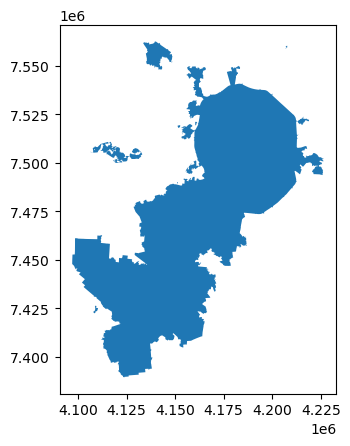

In [171]:
import geopandas as gpd
import osmnx as ox

# Получаем границы Москвы
city = ox.geocode_to_gdf("Moscow, Russia")[["geometry"]].to_crs(3857)
print(city.crs)
# Визуализируем границы города
city.plot()


## Визуализация банкоматов и точек интереса (POI)

Прежде чем переходить к построению признаков, важно убедиться, что данные корректно загружены и расположены в пределах границ города.  
Для этого выполняем визуализацию:

1. **Границы Москвы** — полигон города, в пределах которого проводится анализ.  
2. **Банкоматы (ATM)** — целевые объекты исследования.  
3. **Точки интереса (POI)** — магазины, кафе, аптеки, остановки и другие объекты, формирующие трафик.

Зачем это нужно:
- Проверка корректности геоданных и проекции.  
- Оценка пространственного распределения объектов:  
  - видим, где банкоматы уже стоят;  
  - где сосредоточены объекты, влияющие на спрос;  
  - какие зоны города пока «пустые».  

Такая визуализация даёт наглядное понимание исходной картины и закладывает основу для построения будущих признаков.


C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\1379830173.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[2].legend()


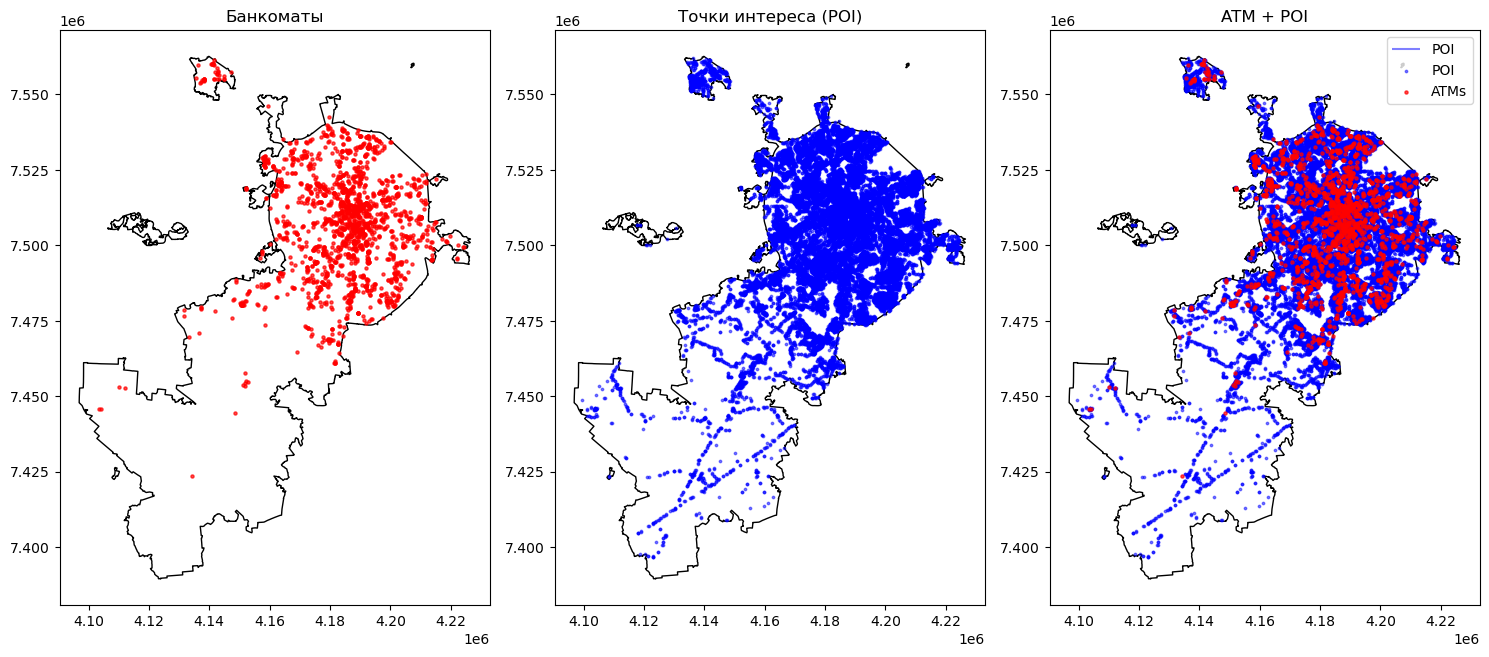

In [172]:
import matplotlib.pyplot as plt
# Строим карту
fig, axes = plt.subplots(1, 3, figsize=(15, 10))


# POI
city.plot(ax=axes[1], facecolor="none", edgecolor="black")
poi.plot(ax=axes[1], color="blue", markersize=3, alpha=0.5)
axes[1].set_title("Точки интереса (POI)")

# Банкоматы
city.plot(ax=axes[0], facecolor="none", edgecolor="black")
atm.plot(ax=axes[0], color="red", markersize=5, alpha=0.7)
axes[0].set_title("Банкоматы")

# Совместное распределение
city.plot(ax=axes[2], facecolor="none", edgecolor="black")

poi.plot(ax=axes[2], color="blue", markersize=3, alpha=0.5, label="POI")
atm.plot(ax=axes[2], color="red", markersize=5, alpha=0.7, label="ATMs")
axes[2].set_title("ATM + POI")
axes[2].legend()

plt.tight_layout()
plt.show()


### Ограничение анализа территорией внутри МКАД

На графиках видно, что в «Новой Москве» плотность банкоматов и POI низкая, что искажает анализ.  
Чтобы сосредоточиться на основной городской части, ограничиваем данные территорией внутри **МКАД**.  

Для этого:  
1. Загружаем линию МКАД из OSM.  
2. Превращаем её в полигон (buffer).  
3. Фильтруем ATM и POI, оставляя только объекты внутри кольца.  

Так модель будет работать по компактной и репрезентативной части города.


Для работы с геометрическими объектами применяется библиотека **Shapely**.  
Она используется совместно с GeoPandas и обеспечивает базовые операции над геометрией:

- создание точек (`Point`), линий и полигонов;  
- построение буферов вокруг объектов (`buffer`);  
- проверка пространственных отношений (`within`, `intersects`).  

В нашем проекте Shapely нужен для генерации сетки точек-кандидатов и расчёта окружения (объекты POI в радиусе 300–500 м).


C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\2265082721.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mkad_buffer = mkad.buffer(100).unary_union        # расширяем немного, чтобы замкнулось


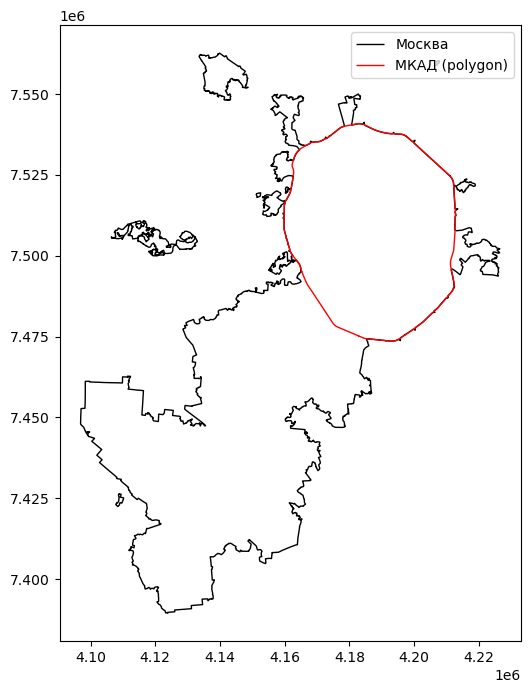

In [173]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union
from shapely.geometry import Polygon

# Загружаем все trunk-дороги с тегом name
tags = {"highway": "trunk"}
roads = ox.features_from_place("Moscow, Russia", tags).to_crs(3857)

# Фильтруем только МКАД по названию
mkad = roads[roads["name"].str.contains("МКАД", na=False)]

# Превращаем линию МКАД в полигон
mkad_buffer = mkad.buffer(100).unary_union        # расширяем немного, чтобы замкнулось
mkad_polygon = Polygon(mkad_buffer.exterior)      # берём внешнюю границу как полигон
mkad_gdf = gpd.GeoDataFrame(geometry=[mkad_polygon], crs=mkad.crs)

# Загружаем всю Москву
city = ox.geocode_to_gdf("Moscow, Russia")[["geometry"]].to_crs(3857)

# Визуализация
fig, ax = plt.subplots(figsize=(8, 8))
city.boundary.plot(ax=ax, color="black", linewidth=1, label="Москва")
mkad_gdf.boundary.plot(ax=ax, color="red", linewidth=1, label="МКАД (polygon)")
plt.legend()
plt.show()


Теперь нужно обрезать все наборы данных — оставить только объекты, которые лежат внутри этой границы для банкоматов и точек интереса.

In [174]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Загружаем границу Москвы
city = ox.geocode_to_gdf("Moscow, Russia")[["geometry"]].to_crs(3857)

# Линии МКАД
tags = {"highway": "trunk"}
roads = ox.features_from_place("Moscow, Russia", tags).to_crs(3857)
mkad = roads[roads["name"].str.contains("МКАД", na=False)]

# Объединяем линии
mkad_line = mkad.unary_union

# Буфер вокруг линии (толщина кольца)
mkad_buffer = mkad_line.buffer(200)

# Внутренняя граница бублика = interiors[0]
mkad_inner = Polygon(list(mkad_buffer.interiors[0].coords))
mkad_inner_gdf = gpd.GeoDataFrame(geometry=[mkad_inner], crs=city.crs)

# Пересекаем с Москвой → Москва в пределах МКАД
moscow_within_mkad = gpd.overlay(city, mkad_inner_gdf, how="intersection")

# Обрезаем ATM и POI
atm_in_mkad = atm[atm.within(moscow_within_mkad.unary_union)]
poi_in_mkad = poi[poi.within(moscow_within_mkad.unary_union)]

print("ATM до:", len(atm), " → после:", len(atm_in_mkad))
print("POI до:", len(poi), " → после:", len(poi_in_mkad))

C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\4050460731.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mkad_line = mkad.unary_union
C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\4050460731.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  atm_in_mkad = atm[atm.within(moscow_within_mkad.unary_union)]
C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\4050460731.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  poi_in_mkad = poi[poi.within(moscow_within_mkad.unary_union)]


ATM до: 2059  → после: 1790
POI до: 33848  → после: 27337


C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\2993437576.py:8: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


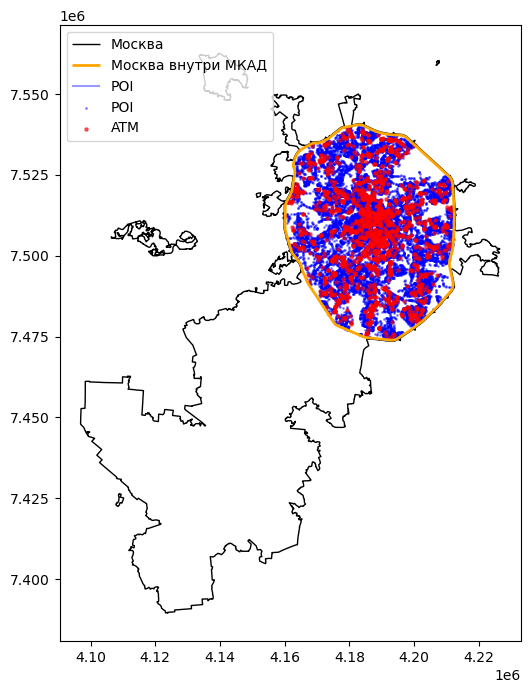

In [175]:
# Визуализация
fig, ax = plt.subplots(figsize=(8, 8))
city.boundary.plot(ax=ax, color="black", linewidth=1, label="Москва")
moscow_within_mkad.boundary.plot(ax=ax, color="orange", linewidth=2, label="Москва внутри МКАД")
poi_in_mkad.plot(ax=ax, color="blue", markersize=1, alpha=0.4, label="POI")
atm_in_mkad.plot(ax=ax, color="red", markersize=5, alpha=0.6, label="ATM")

plt.legend()
plt.show()


C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\1271663941.py:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[2].legend()


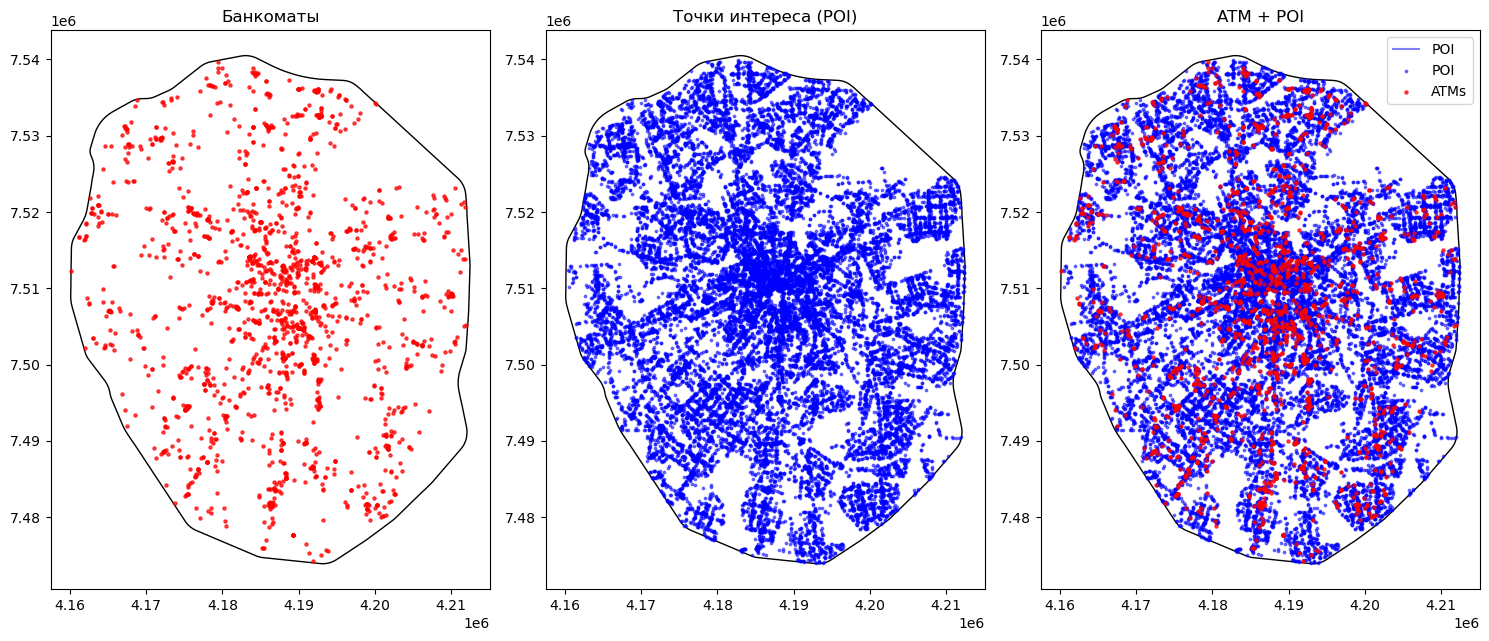

In [181]:
# Проверяем наложение в пределах МКАД

import matplotlib.pyplot as plt
# Строим карту
fig, axes = plt.subplots(1, 3, figsize=(15, 10))


# POI
moscow_within_mkad.plot(ax=axes[1], facecolor="none", edgecolor="black")
poi_in_mkad.plot(ax=axes[1], color="blue", markersize=3, alpha=0.5)
axes[1].set_title("Точки интереса (POI)")

# Банкоматы
moscow_within_mkad.plot(ax=axes[0], facecolor="none", edgecolor="black")
atm_in_mkad.plot(ax=axes[0], color="red", markersize=5, alpha=0.7)
axes[0].set_title("Банкоматы")

# Совместное распределение
moscow_within_mkad.plot(ax=axes[2], facecolor="none", edgecolor="black")

poi_in_mkad.plot(ax=axes[2], color="blue", markersize=3, alpha=0.5, label="POI")
atm_in_mkad.plot(ax=axes[2], color="red", markersize=5, alpha=0.7, label="ATMs")
axes[2].set_title("ATM + POI")
axes[2].legend()

plt.tight_layout()
plt.show()

После построения полигона внутри МКАД данные ограничены только этой территорией.  
Это позволяет исключить «новую Москву», где плотность объектов мала и они могли бы исказить анализ.

**Результат:**
- Банкоматы (ATM): `2059 → 1790`
- Точки интереса (POI): `32619 → 26271`

Таким образом, остались только релевантные данные для анализа спроса и размещения банкоматов в пределах МКАД.

## Формирование сетки точек-кандидатов

Для анализа потенциальных мест установки банкоматов мы создаём **сетку точек-кандидатов** внутри границ Москвы.  
Идея: сравнивать не только уже существующие банкоматы, но и «виртуальные локации» — равномерно расставленные по городу точки, которые можно рассматривать как возможные места установки.

Подход:
1. Берём геометрию Москвы (полигон границ города).  
2. Строим регулярную сетку с шагом 500 метров.  
3. Оставляем только те точки, которые попадают внутрь границ города.  
4. Получаем равномерное покрытие Москвы, где каждая точка может стать кандидатом для анализа.

Зачем это нужно:
- Для **реальных банкоматов** мы знаем метку: объект существует → `1`.  
- Для **точек-кандидатов** метка пока отсутствует: банкомата нет → `0`.  

Таким образом формируется единый датасет, где каждая точка (реальная или кандидат) описывается признаками:  
- число магазинов, кафе, аптек поблизости;  
- количество соседних банкоматов;  
- расстояния до ближайших объектов.  

Дальше эта информация позволит поставить задачу классификации: какие признаки отличают места, где банкоматы реально стоят, от тех, где их нет.


In [201]:
import numpy as np
from shapely.geometry import Point

# Шаг сетки (в метрах)
grid_step = 500  

# Получаем границы города
bounds = city.total_bounds  # (minx, miny, maxx, maxy)

# Формируем сетку координат
x_coords = np.arange(bounds[0], bounds[2], grid_step)
y_coords = np.arange(bounds[1], bounds[3], grid_step)

# Создаём точки
points = [Point(x, y) for x in x_coords for y in y_coords]

# Переводим в GeoDataFrame
grid = gpd.GeoDataFrame(geometry=points, crs=3857)

# Оставляем только точки внутри Москвы
grid = grid[grid.geometry.within(city.iloc[0].geometry)]

print("Количество точек-кандидатов:", len(grid))
grid.head()


Количество точек-кандидатов: 31974


,geometry
463,POINT (4097402.485 7447508.321)
464,POINT (4097402.485 7448008.321)
465,POINT (4097402.485 7448508.321)
466,POINT (4097402.485 7449008.321)
467,POINT (4097402.485 7449508.321)


## Объединение ATM и точек-кандидатов  

На этом шаге формируем **базовый набор точек** для дальнейших расчётов.  

**Подход:**  
1. Для каждого реального банкомата (`atm_in_mkad`) проставляем метку `target = 1`.  
2. Для каждой точки регулярной сетки (`grid`) проставляем метку `target = 0`.  
3. Объединяем оба набора в один `GeoDataFrame` → `all_points`.  

**Зачем это нужно:**  
- Создаём единую выборку, где каждая точка имеет координаты и целевую метку.  
- Это основа для дальнейших шагов: к этим точкам будут добавляться признаки окружения (POI, близость других банкоматов и т.д.).  
- Итоговый датасет становится пригодным для постановки задачи бинарной классификации: *где банкомат есть, а где его нет*.  

**Результат:**  
- Координаты точек (геометрия).  
- Целевая метка наличия банкомата (`target = 1` или `0`).  


### Формирование единого датасета

Фильтруем точки-кандидаты внутри МКАД, проставляем метки (`target = 0` для кандидатов, `target = 1` для банкоматов) и объединяем оба набора в единый датасет.


In [202]:
# Фильтруем кандидатов внутри МКАД
candidates = grid[grid.within(moscow_within_mkad.unary_union)].copy()
candidates["target"] = 0

# Метка для банкоматов
atm_in_mkad = atm_in_mkad.copy()
atm_in_mkad["target"] = 1

# Объединяем в единый датасет
all_points = pd.concat([atm_in_mkad, candidates], ignore_index=True)

# Удаляем метки расположения банкоматов внутри МКАД
all_points.drop(columns=['poi_within_500m'], errors='ignore', inplace=True)
all_points.head()

C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\3747934250.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  candidates = grid[grid.within(moscow_within_mkad.unary_union)].copy()


,element,id,amenity,operator,brand,cash_in,opening_hours,geometry,target
0,node,408385048.0,atm,ПАО Сбербанк,Сбербанк,None,24/7,POINT (4196915.311 7510726.416),1
1,node,432502063.0,atm,Банк ВТБ (ПАО),ВТБ,None,None,POINT (4185805.169 7514516.401),1
2,node,444776906.0,atm,Альфа-Банк,Альфа-Банк,None,None,POINT (4177131.132 7519551.711),1
3,node,444776911.0,atm,"ПАО ""МОСКОВСКИЙ КРЕДИТНЫЙ БАНК""",None,None,Mo-Su 09:00-23:00,POINT (4166893.201 7530062.632),1
4,node,444776938.0,atm,"АО ""Альфа-Банк""",Альфа-Банк,None,None,POINT (4174947.512 7507443.094),1


**Проверка датасета**

Считаем общее количество объектов, распределение по классам и баланс выборки.

In [203]:
# Выводим статистику
summary = pd.DataFrame({
    "Тип": ["Кандидаты", "ATM", "Итого"],
    "Количество": [
        len(candidates),
        len(atm_in_mkad),
        len(all_points)
    ]
})

print("Размер итогового датасета:", all_points.shape)
print(all_points["target"].value_counts(normalize=True))

display(summary)


Размер итогового датасета: (12585, 9)
target
0    0.857767
1    0.142233
Name: proportion, dtype: float64


,Тип,Количество
0,Кандидаты,10795
1,ATM,1790
2,Итого,12585


### Визуализация в границах МКАД

Строим карту: зелёные точки — кандидаты, красные — реальные банкоматы.


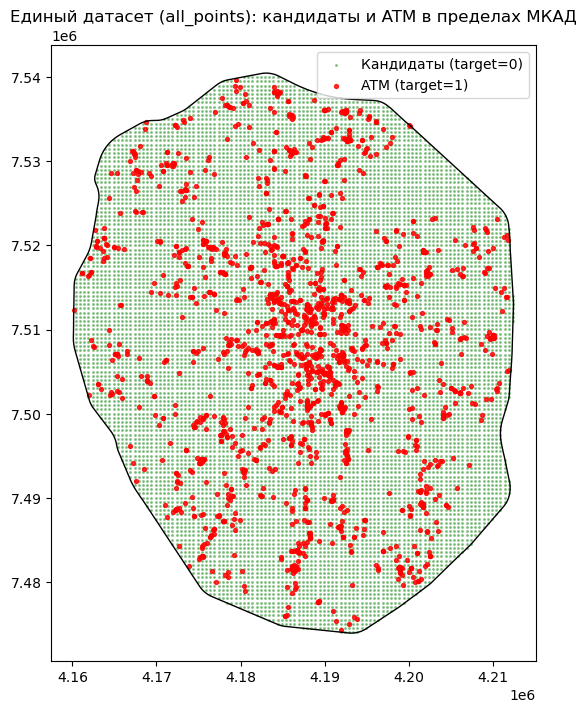

In [204]:
fig, ax = plt.subplots(figsize=(8, 8))
moscow_within_mkad.boundary.plot(ax=ax, color="black", linewidth=1)

cand = all_points.query("target == 0")
atm  = all_points.query("target == 1")

cand.plot(ax=ax, markersize=1.5, color="green", alpha=0.35, label="Кандидаты (target=0)")
atm.plot(ax=ax,  markersize=8,   color="red",   alpha=0.8,  label="ATM (target=1)")

plt.title("Единый датасет (all_points): кандидаты и ATM в пределах МКАД")
plt.legend(); plt.show()


**Итоги объединения ATM и кандидатов**

 atm_in_mkad — реальные банкоматы (метка target = 1)  
 candidates — сетка точек-кандидатов (метка target = 0)  
 all_points — объединённый датасет для анализа и генерации признаков  
 
- Внутри границ МКАД осталось **12 585 кандидатов** (метка = 0).  
- Реальных банкоматов (метка = 1): **1 790**.  
- Всего в датасете: **12 585 точек**.  
- Баланс классов: ~86% кандидатов и ~14% банкоматов.  

Таким образом, получена единая основа для дальнейшего анализа: реальные банкоматы и виртуальные кандидаты в едином пространстве.  
Несмотря на перекос классов, это отражает реальную ситуацию и будет учтено при построении модели.


# План по разделу "Построение признаков"

1. Построение признаков по категориям POI
- **Задача**: посчитать для каждой точки (банкомат или кандидат) количество объектов разных типов (магазины, кафе, аптеки, транспорт и др.) в радиусах 300 м и 500 м.  
- **Результат**: новые признаки вида `poi_sum_300`, `poi_sum_500`, и т.д.

2. Расчёт признака "количество объектов рядом"
- **Задача**: агрегировать все POI без деления на категории и посчитать их количество в радиусах 300 м и 500 м.  
- **Результат**: признаки `poi_sum_300`, `poi_sum_500`.

3. Визуализация распределения банкоматов
- **Задача**: проверить корректность построения признаков, визуализировать плотность банкоматов и распределение по городу.  
- **Результат**: тепловая карта/карта плотности банкоматов.

Для анализа факторов, влияющих на размещение банкоматов, формируем набор признаков на основе пространственных данных. Признаки считаются для всех точек итогового датасета (реальные банкоматы и кандидаты).

**Результат**
В итоге получена матрица признаков размером **12 585 × 12**, которая будет использоваться для дальнейшего анализа и построения модели.


## Признаки по категориям POI

Категории выбраны исходя из значимости для спроса на банкоматы:  
- **cafe, restaurant** — места с высокой проходимостью;  
- **pharmacy** — социально значимые объекты;  
- **shop** — регулярные покупки;  
- **bus_stop** — транспортная доступность.  

**Построение признаков**

Для каждой точки (банкомат или кандидат) считаем количество POI в радиусах 300 м и 500 м.  
Получаем новые признаки: `cafe_300`, `cafe_500`, `pharmacy_300`, `shop_500`, `bus_stop_300` и т.д.

**Результат**

- Размер матрицы признаков: **12 585 × 10**  
- Для каждой точки есть набор признаков, описывающих количество POI по категориям в радиусах 300 и 500 м.


### Проверка данных POI

Перед расчётом признаков проверим структуру данных: типы геометрий и основные категории объектов.


In [205]:
# Проверка структуры POI
import pandas as pd

# Типы геометрий
geom_types = poi_in_mkad.geom_type.value_counts()

# Топ категорий
top_categories = {
    "amenity": poi_in_mkad["amenity"].value_counts().head(5),
    "shop": poi_in_mkad["shop"].value_counts().head(5),
    "highway": poi_in_mkad["highway"].value_counts().head(5),
    "public_transport": poi_in_mkad["public_transport"].value_counts().head(5)
}

# Подсчёт типов геометрий с долями
geom_types = poi_in_mkad.geom_type.value_counts(normalize=False)
geom_percent = poi_in_mkad.geom_type.value_counts(normalize=True) * 100

geom_summary = pd.DataFrame({
    "count": geom_types,
    "%": geom_percent.round(2)
})

display(geom_summary)

# Объединим в одну таблицу
summary = pd.concat(top_categories, axis=1)
print("\nТоп категорий POI:")
display(summary)


,count,%
Point,26754,97.87
Polygon,582,2.13
LineString,1,0.00



Топ категорий POI:


,amenity,shop,highway,public_transport
cafe,4565.0,NaN,NaN,NaN
pharmacy,3829.0,NaN,NaN,NaN
restaurant,2531.0,NaN,NaN,NaN
fast_food,29.0,NaN,NaN,NaN
device_charging_station,3.0,NaN,NaN,NaN
convenience,NaN,3593.0,NaN,NaN
supermarket,NaN,2886.0,NaN,NaN
food,NaN,97.0,NaN,NaN
bakery,NaN,87.0,NaN,NaN
confectionery,NaN,10.0,NaN,NaN


**Проверка данных POI**

- Основной массив объектов представлен **точками (98%)**, полигоны встречаются редко.  
- Основные категории POI:  
  - кафе — 4555  
  - аптеки — 3831  
  - рестораны — 2532  
  - магазины (convenience/supermarket) — 6481  
  - остановки общественного транспорта — 8895  

### Расчёт признаков POI (300 м и 500 м)

Для каждой точки (и реальных ATM, и кандидатов) посчитать количество объектов инфраструктуры вокруг: кафе, рестораны, аптеки, магазины, автобусные остановки.
Почему так. Считаем одним и тем же кодом для всех точек, в метрах — это исключает утечки и даёт честные признаки.
Результат. На выходе получаем признаки cafe_300, cafe_500, …, а также агрегаты poi_sum_300, poi_sum_500

In [206]:
# Настройки и проверка CRS
import pandas as pd
import geopandas as gpd
import numpy as np

# Категории POI 
poi_categories = {
    "cafe":       ("amenity", "cafe"),
    "restaurant": ("amenity", "restaurant"),
    "pharmacy":   ("amenity", "pharmacy"),
    "shop":       ("shop",    ["supermarket", "convenience"]),
    "bus_stop":   ("highway", "bus_stop"),
}

# Перевод в метры 
def to_meters_crs(gdf: gpd.GeoDataFrame, epsg=3857) -> gpd.GeoDataFrame:
    if gdf.crs is None:
        raise ValueError()
    return gdf if gdf.crs.to_epsg() == epsg else gdf.to_crs(epsg)

points_m = to_meters_crs(all_points)     # точки (ATM + кандидаты)
pois_m   = to_meters_crs(poi_in_mkad)    # POI внутри МКАД


In [207]:
#  Функция подсчёта в радиусе
def count_poi_in_radius(points_gdf, pois_gdf, col, values, radius_m, out_col):
    vals = values if isinstance(values, list) else [values]
    subset = pois_gdf[pois_gdf[col].isin(vals)][["geometry"]].copy()

    buffers = points_gdf[["geometry"]].copy()
    buffers["geometry"] = buffers.geometry.buffer(radius_m)

    joined = gpd.sjoin(subset, buffers, how="inner", predicate="within")
    counts = joined.groupby("index_right").size().reindex(points_gdf.index, fill_value=0)
    return pd.DataFrame({out_col: counts.astype(int)}, index=points_gdf.index)


In [208]:
#  Построение признаков
features = []

for radius in [300, 500]:
    for key, (col, values) in poi_categories.items():
        feat = count_poi_in_radius(points_m, pois_m, col, values, radius, f"{key}_{radius}")
        features.append(feat)

poi_features = pd.concat(features, axis=1).fillna(0).astype(int)

print("Размер матрицы признаков:", poi_features.shape)
poi_features.head()


Размер матрицы признаков: (12585, 10)


,cafe_300,restaurant_300,pharmacy_300,shop_300,bus_stop_300,cafe_500,restaurant_500,pharmacy_500,shop_500,bus_stop_500
0,0,0,1,1,1,2,0,1,4,3
1,11,2,6,5,2,29,4,11,6,4
2,0,0,0,0,0,11,3,1,2,2
3,1,0,2,1,4,2,0,2,6,4
4,6,1,1,0,0,13,2,1,1,3


**Результат**

- Размер матрицы признаков: **12 585 × 10**  
- Для каждой точки есть набор признаков, описывающих количество POI по категориям в радиусах 300 и 500 м.

### Суммарное количество объектов рядом

Помимо отдельных категорий (кафе, аптеки, магазины и т.д.), полезно иметь суммарный показатель доступности.  
Он отражает, насколько «оживлённое» место вокруг точки, и может выступать как обобщающий индикатор плотности окружения.

**Логика:**  
Для каждой точки считаем общее количество POI в радиусах 300 м и 500 м.  

**Результат:**  
Добавлены два новых признака:  
- `poi_sum_300` — общее количество объектов в радиусе 300 м;  
- `poi_sum_500` — общее количество объектов в радиусе 500 м.  

Эти признаки показывают общую насыщенность территории и будут дополнительно учитываться моделью.


In [215]:

# агрегируем по всем категориям
cols_300 = [c for c in poi_features.columns if c.endswith("_300")]
cols_500 = [c for c in poi_features.columns if c.endswith("_500")]

poi_features["poi_sum_300"] = poi_features[cols_300].sum(axis=1)
poi_features["poi_sum_500"] = poi_features[cols_500].sum(axis=1)

# смотрим результат
print("Пример новых признаков:")
poi_features[["poi_sum_300","poi_sum_500"]].head()


Пример новых признаков:


,poi_sum_300,poi_sum_500
0,6,20
1,52,108
2,0,38
3,16,28
4,16,40


In [216]:
# Пример сформированных признаков
cols = [
    "cafe_300", "restaurant_300", "pharmacy_300", "shop_300", "bus_stop_300", "poi_sum_300",
    "cafe_500", "restaurant_500", "pharmacy_500", "shop_500", "bus_stop_500", "poi_sum_500"
]

display(poi_features[cols].shape)
display(poi_features[cols].head())


(12585, 12)

,cafe_300,restaurant_300,pharmacy_300,shop_300,bus_stop_300,poi_sum_300,cafe_500,restaurant_500,pharmacy_500,shop_500,bus_stop_500,poi_sum_500
0,0,0,1,1,1,6,2,0,1,4,3,20
1,11,2,6,5,2,52,29,4,11,6,4,108
2,0,0,0,0,0,0,11,3,1,2,2,38
3,1,0,2,1,4,16,2,0,2,6,4,28
4,6,1,1,0,0,16,13,2,1,1,3,40


### Вывод по разделу "Построение признаков"

На основе данных POI для каждой точки (банкоматы и кандидаты) были рассчитаны признаки, описывающие окружение в радиусах 300 и 500 м.  
Сформированы показатели по ключевым категориям (кафе, аптеки, магазины, остановки транспорта), а также агрегированные признаки `poi_sum_300` и `poi_sum_500`, отражающие общую насыщенность территории объектами.  

В итоге получена матрица признаков размером **12 585 × 12**, которая будет использоваться для дальнейшего анализа и построения модели.


# Визуализация распределения банкоматов

Теперь посмотрим, как банкоматы распределены по Москве.

Задачи визуализации:
- показать общую картину по городу;
- выделить районы с высокой и низкой обеспеченностью;
- привести наглядный пример по станциям метро;
- подтвердить работу сетки кандидатов через тепловую карту.

### Основные результаты
- В центре города банкоматов значительно больше, чем на окраинах.  
- Лидеры по плотности: **Замоскворечье, Тверской, Арбат**.  
- Аутсайдеры: **Метрогородок, Алтуфьевский, Бескудниковский**.  
- По метро: у **Курской** в радиусе 300 м — 23 банкомата, а у некоторых станций — всего 1.

Визуализация помогает убедиться, что данные корректны, и показывает основные закономерности для дальнейшего анализа.


### Тепловая карта по сетке кандидатов

Сначала построим тепловую карту, которая показывает концентрацию банкоматов на территории Москвы.  
Это позволит убедиться, что сетка кандидатов и рассчитанные признаки работают корректно: в центре города плотность выше, на окраинах — ниже.


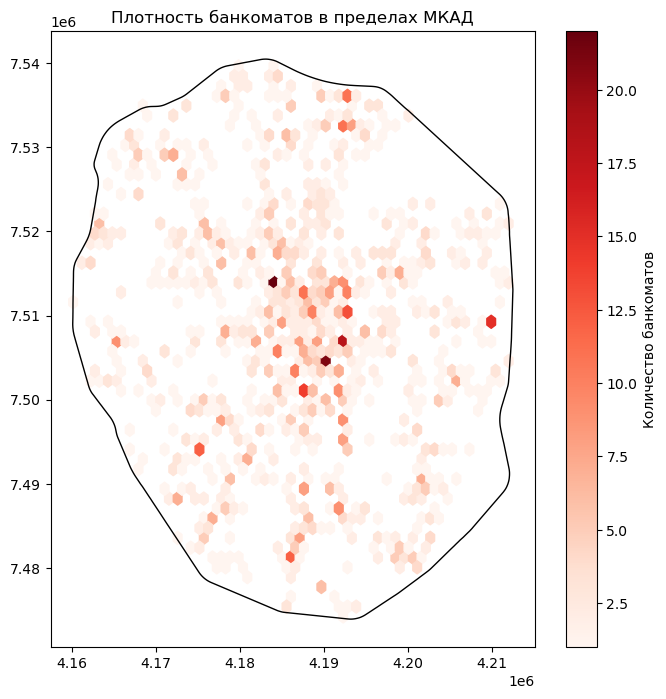

In [292]:
# Визуализация тепловой карты
fig, ax = plt.subplots(figsize=(8, 8))

# Границы Москвы
moscow_within_mkad.boundary.plot(ax=ax, color="black", linewidth=1)

# Тепловая карта по банкоматам (hexbin)
hb = ax.hexbin(
    atm_in_mkad.geometry.x,
    atm_in_mkad.geometry.y,
    gridsize=50,   # размер "сетки" (чем меньше, тем детальнее)
    cmap="Reds",
    mincnt=1,      # показывать только ячейки с хотя бы 1 банкоматом
)

plt.colorbar(hb, ax=ax, label="Количество банкоматов")
plt.title("Плотность банкоматов в пределах МКАД")
plt.show()


**Анализ тепловой карты**

По результатам построения тепловой карты наблюдается четкая концентрация банкоматов в центральной части Москвы. Наибольшая плотность отмечается в пределах Садового кольца, с постепенным уменьшением к периферийным районам.

### Плотность банкоматов по районам

Теперь рассмотрим распределение банкоматов по административным районам Москвы.  
Для этого считаем количество банкоматов, приводим его к площади района и строим показатель плотности (шт./км²).  
Это позволяет сравнивать районы между собой независимо от их размеров.

Построим карту с выделением районов-лидеров и аутсайдеров по плотности банкоматов.  
Центральные районы традиционно входят в топ, а периферийные территории — в анти-топ.



In [293]:
import geopandas as gpd
import osmnx as ox

#  Районы Москвы 
tags_districts = {"boundary": "administrative", "admin_level": "9"}
districts = ox.features_from_place("Moscow, Russia", tags_districts).to_crs(3857)

# Берём только полигоны
districts = districts[districts.geometry.type.isin(["Polygon", "MultiPolygon"])]

#  Обрезаем по МКАД 
districts_in_mkad = gpd.overlay(districts, moscow_within_mkad, how="intersection")

print("Количество районов до:", len(districts), " → после:", len(districts_in_mkad))


Количество районов до: 219  → после: 137


In [294]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd

# параметры
radius_metro = 300   # радиус вокруг метро в метрах
top_n = 5            # количество топовых элементов

# районы
districts_in_mkad = districts_in_mkad.reset_index(drop=True)
districts_in_mkad["district"] = districts_in_mkad["name"].astype(str)
districts_in_mkad["area_km2"] = districts_in_mkad.to_crs(3857).area / 10**6

# банкоматы по районам
atm_with_districts = gpd.sjoin(atm_in_mkad, districts_in_mkad, how="inner", predicate="within")
atm_counts = atm_with_districts.groupby("district").size().reset_index(name="atm_count")

# статистика по районам
districts_stats = districts_in_mkad.merge(atm_counts, on="district", how="left")
districts_stats["atm_count"] = districts_stats["atm_count"].fillna(0)
districts_stats["atm_density"] = districts_stats["atm_count"] / districts_stats["area_km2"]


# фильтрация (убираем "Москва" и слишком большие территории)
districts_stats_filtered = districts_stats[
    ~districts_stats["district"].str.contains("Москва", na=False) &
    (districts_stats["area_km2"] < 100)
]

# станции метро
tags_metro = {"railway": "station", "station": "subway"}
metro = ox.features_from_place("Moscow, Russia", tags_metro).to_crs(3857)
metro_in_mkad = metro[metro.within(moscow_within_mkad.unary_union)].copy().reset_index(drop=True)

# названия станций
station_names = metro_in_mkad["name"].copy()
station_names[station_names.isna()] = "station_" + metro_in_mkad.index[station_names.isna()].astype(str)
metro_in_mkad["station"] = station_names

# банкоматы в радиусе
metro_buffers = metro_in_mkad.copy()
metro_buffers["geometry"] = metro_buffers.buffer(radius_metro)
atm_near_metro = gpd.sjoin(atm_in_mkad, metro_buffers, how="inner", predicate="within")

# статистика по метро
metro_counts = atm_near_metro.groupby("station").size().reset_index(name="atm_count")

# Топ, анти-топ районов (ОДНО ИМЯ ДЛЯ ВСЕХ)
top5_districts = districts_stats_filtered.sort_values("atm_density", ascending=False).head(top_n)
anti_top5_districts = districts_stats_filtered.sort_values("atm_density", ascending=True).head(top_n)

C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\3919803250.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  metro_in_mkad = metro[metro.within(moscow_within_mkad.unary_union)].copy().reset_index(drop=True)


C:\Users\agurskiy\AppData\Local\Temp\ipykernel_5516\3413170504.py:39: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


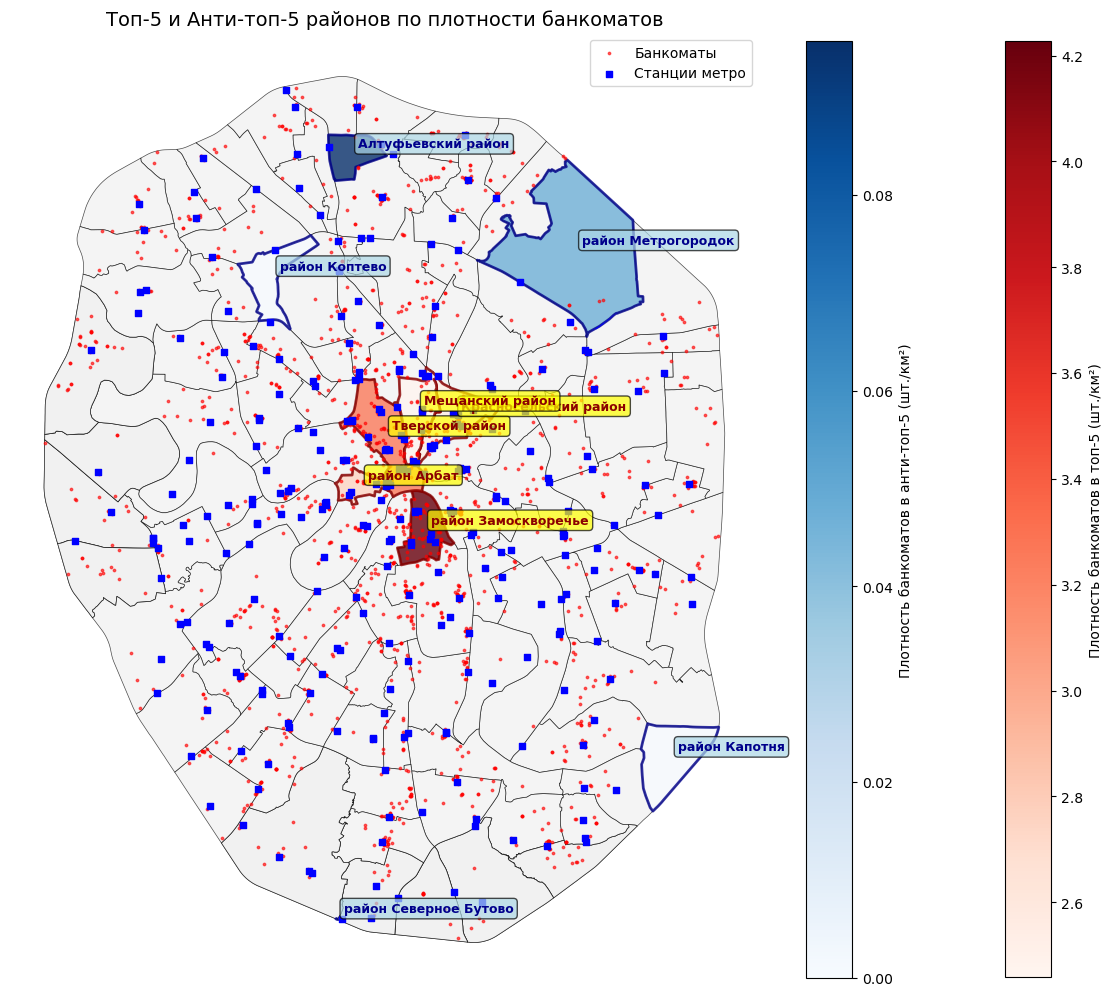

In [295]:
# Визуализация районов
fig, ax = plt.subplots(figsize=(12, 12))

# базовая карта
districts_stats_filtered.plot(ax=ax, color="#f0f0f0", edgecolor="black", linewidth=0.5, alpha=0.7)

# подсветка топ-5 (красные) с тепловой шкалой
top5_districts.plot(ax=ax, column="atm_density", cmap="Reds", edgecolor="darkred", 
                   linewidth=2, alpha=0.8, legend=True,
                   legend_kwds={'label': "Плотность банкоматов в топ-5 (шт./км²)",
                               'orientation': "vertical", 'shrink': 0.8})

# подсветка анти-топ-5 (синие) с тепловой шкалой
anti_top5_districts.plot(ax=ax, column="atm_density", cmap="Blues", edgecolor="darkblue", 
                    linewidth=2, alpha=0.8, legend=True,
                    legend_kwds={'label': "Плотность банкоматов в анти-топ-5 (шт./км²)",
                                'orientation': "vertical", 'shrink': 0.8})

# точки банкоматов и метро
atm_in_mkad.plot(ax=ax, color="red", markersize=3, alpha=0.6, label="Банкоматы")
metro_in_mkad.plot(ax=ax, color="blue", markersize=20, marker="s", label="Станции метро")

# подписи для топ-районов (ИСПРАВЛЕННЫЕ ПЕРЕМЕННЫЕ)
for _, row in pd.concat([top5_districts, anti_top5_districts]).iterrows():
    centroid = row.geometry.centroid
    plt.annotate(
        text=row["district"], 
        xy=(centroid.x, centroid.y), 
        xytext=(5, 5), textcoords="offset points",
        fontsize=9, fontweight="bold", 
        color="darkred" if row["district"] in top5_districts["district"].values else "darkblue",
        bbox=dict(boxstyle="round,pad=0.3", 
                 facecolor="yellow" if row["district"] in top5_districts["district"].values else "lightblue", 
                 alpha=0.7)
    )

plt.title("Топ-5 и Анти-топ-5 районов по плотности банкоматов", fontsize=14)
plt.axis("off")
plt.legend()
plt.tight_layout()
plt.show()

In [296]:
# Вывод результатов: топ-5 (УБРАТЬ ДУБЛИРОВАНИЕ РАСЧЕТА)
print("Топ-5 районов по плотности банкоматов")
for i, (idx, row) in enumerate(top5_districts.iterrows(), 1):
    print(f"{i}. {row['district']:25} | {row['atm_count']:3.0f} шт. | "
          f"{row['area_km2']:6.2f} км² | {row['atm_density']:6.2f} шт./км²")

print(f"\nТоп-5 станций метро по количеству банкоматов в радиусе {radius_metro} м")  # ИСПРАВЛЕН РАДИУС
top5_metro = metro_counts.sort_values("atm_count", ascending=False).head(top_n)
for i, (idx, row) in enumerate(top5_metro.iterrows(), 1):
    print(f"{i}. {row['station']:30} | {row['atm_count']:3.0f} банкоматов")

# Вывод результатов: анти-топ-5
print("\nАнти-топ-5 районов по плотности банкоматов")
for i, (idx, row) in enumerate(anti_top5_districts.iterrows(), 1):
    print(f"{i}. {row['district']:25} | {row['atm_count']:3.0f} шт. | "
          f"{row['area_km2']:6.2f} км² | {row['atm_density']:6.2f} шт./км²")

print(f"\nАнти-топ-5 станций метро по количеству банкоматов в радиусе {radius_metro} м")  # ИСПРАВЛЕН РАДИУС
anti_top5_metro = metro_counts.sort_values("atm_count", ascending=True).head(top_n)
for i, (idx, row) in enumerate(anti_top5_metro.iterrows(), 1):
    print(f"{i}. {row['station']:30} | {row['atm_count']:3.0f} банкоматов")

Топ-5 районов по плотности банкоматов
1. район Замоскворечье       |  57 шт. |  13.49 км² |   4.23 шт./км²
2. Тверской район            |  75 шт. |  23.03 км² |   3.26 шт./км²
3. район Арбат               |  18 шт. |   6.56 км² |   2.74 шт./км²
4. Красносельский район      |  40 шт. |  15.75 км² |   2.54 шт./км²
5. Мещанский район           |  35 шт. |  14.24 км² |   2.46 шт./км²

Топ-5 станций метро по количеству банкоматов в радиусе 300 м
1. Курская                        |  23 банкоматов
2. Бабушкинская                   |  15 банкоматов
3. Комсомольская                  |  14 банкоматов
4. Москва-Пассажирская-Павелецкая |  14 банкоматов
5. Павелецкая                     |  13 банкоматов

Анти-топ-5 районов по плотности банкоматов
1. район Северное Бутово     |   0 шт. |   0.00 км² |   0.00 шт./км²
2. район Капотня             |   0 шт. |  22.75 км² |   0.00 шт./км²
3. район Коптево             |   0 шт. |  15.17 км² |   0.00 шт./км²
4. район Метрогородок        |   4 шт. |  85.02 к


### Итоги визуализации


- **Центральные районы Москвы** (Замоскворечье, Тверской, Арбат, Мещанский) демонстрируют самую высокую плотность банкоматов — от 2,5 до 4,3 банкомата на км².  
- **Периферийные районы** (Северное Бутово, Капотня, Коптево, Метрогородок, Алтуфьевский) практически лишены банкоматов: плотность от 0 до 0,13 банкомата на км².  
- **По метрополитену**: станция Курская выделяется как лидер по обеспеченности (23 банкомата в радиусе 300 м), в то время как ряд станций (Яхромская, Менделеевская, Севастопольская и др.) имеют лишь по одному банкомату.  

### Вывод:
В матрице признаков чётко проявляются различия в обеспеченности банковской инфраструктурой:  
- центр города перенасыщен,  
- периферия испытывает явный дефицит.  



# Финальный датасет

На предыдущих шагах были рассчитаны признаки для сетки точек-кандидатов:  
- **Инфраструктура (POI):** количество кафе, аптек, магазинов, остановок в радиусах 300 и 500 м;  
- **Конкуренция (ATM):** число банкоматов в тех же радиусах;  
- **Целевая переменная (`target`):** 1 — если в точке установлен банкомат, 0 — если это кандидат.  

**Формирование итогового набора**
- Объединили рассчитанные признаки с таблицей `all_points`, где уже содержался `target`.  
- Получили финальный датасет для обучения модели: признаки инфраструктуры + конкуренции + целевая метка.  
- Данные сохранены в двух форматах:  
  • **CSV** (`final_dataset.csv`) — для обучения модели (без геометрии);  
  • **GeoJSON** (`final_dataset.geojson`) — для визуализации на карте (с геометрией).  

**Итог**
- Размер итогового датасета: **12 585 точек × 12 признаков**.  
- Баланс классов: **14,2% положительных (`target=1`) и 85,8% отрицательных (`target=0`)**.  

Таким образом, получен полный набор данных для задачи бинарной классификации:  
мы знаем, где банкоматы реально установлены, и какие факторы объясняют их размещение.


In [297]:
# Формирование итогового датасета

# Объединяем точки (с уже готовым target) и признаки
final_dataset = all_points.join(poi_features)

# Размер и баланс классов
print("Размер итогового датасета:", final_dataset.shape)
print("\nБаланс классов:")
print(final_dataset["target"].value_counts(normalize=True).round(3))

Размер итогового датасета: (12585, 21)

Баланс классов:
target
0    0.858
1    0.142
Name: proportion, dtype: float64


In [298]:
final_dataset.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 12585 entries, 0 to 12584
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   element         1790 non-null   object  
 1   id              1790 non-null   float64 
 2   amenity         1790 non-null   object  
 3   operator        1714 non-null   object  
 4   brand           1484 non-null   object  
 5   cash_in         234 non-null    object  
 6   opening_hours   821 non-null    object  
 7   geometry        12585 non-null  geometry
 8   target          12585 non-null  int64   
 9   cafe_300        12585 non-null  int32   
 10  restaurant_300  12585 non-null  int32   
 11  pharmacy_300    12585 non-null  int32   
 12  shop_300        12585 non-null  int32   
 13  bus_stop_300    12585 non-null  int32   
 14  cafe_500        12585 non-null  int32   
 15  restaurant_500  12585 non-null  int32   
 16  pharmacy_500    12585 non-null  int32   
 17  shop

**Сохранение итогового датасета**

Для удобства сохраняем данные в двух форматах:  

- **CSV** — табличные данные без геометрии, подходят для обучения ML-моделей;  
- **GeoJSON** — с сохранением геометрии, удобно для картографической визуализации и интерактивного анализа.  


In [299]:
# import os

print("Текущая рабочая директория:", os.getcwd())


Текущая рабочая директория: C:\Users\agurskiy\Yandex.Disk\Git_hub\final-project-atm-analysis\notebooks


In [300]:
# # Пути для сохранения
# output_csv = "../data/processed/final_dataset.csv"
# output_geojson = "../data/processed/final_dataset.geojson"

# # CSV: только признаки и target (без geometry)
# final_dataset.drop(columns="geometry").to_csv(output_csv, index=False)

# # GeoJSON: полный датасет с геометрией
# final_dataset.to_file(output_geojson, driver="GeoJSON")
# print(f"Файлы сохранены:\n- {output_csv}\n- {output_geojson}")


## Анализ признаков по целевым классам

Перед обучением модели проверим, чем отличаются точки с банкоматами (`target=1`) от кандидатов (`target=0`).  
Посмотрим сводные характеристики полученных признаков:  
- минимальные и максимальные значения;  
- средние значения;  
- нулевые значения

**Подход:**  
- убираем колонку с геометрией;  
- считаем средние значения признаков отдельно для `target=0` и `target=1`;  
- сравниваем различия.  

**Итог — признаки с наибольшими различиями:**  
- poi_sum_500: 7.6 → 22.0  
- poi_sum_300: 2.7 → 10.5  
- cafe_500: 1.3 → 5.5  

**Вывод:**  
- Банкоматы чаще расположены в местах с развитой инфраструктурой.  
- Особенно сильны различия по общему числу POI и по наличию кафе.  
- Признаки адекватно отражают реальность и будут полезны для модели.


In [301]:
import matplotlib.pyplot as plt
import pandas as pd

# Убираем geometry и оставляем только числовые признаки + target 
features = final_dataset.drop(columns="geometry").select_dtypes(include="number")

# Считаем средние по классам
mean_by_target = features.groupby("target").mean().T

# Добавляем разницу
mean_by_target["diff"] = mean_by_target[1] - mean_by_target[0]

# Дополнительно считаем сводные показатели по всему датасету
mean_by_target["max"] = features.drop(columns="target").max().values
mean_by_target["mean"] = features.drop(columns="target").mean().values
mean_by_target["zero"] = (features.drop(columns="target") == 0).sum().values

# Выбираем топ признаков по абсолютной разнице
top_features = mean_by_target["diff"].abs().sort_values(ascending=False).head(12).index.tolist()
print("\nТоп-4 признаков по различию:", top_features)

# Сводная таблица по ТОП-признакам
print("\nСводная таблица по ТОП-признакам")
summary = mean_by_target.loc[top_features][[0, 1, 'diff', 'max', 'mean', 'zero']].round(3)
summary.columns = ['Без банкомата', 'С банкоматом', 'Разница', 'Макс.', 'Среднее', 'Нулевых']
display(summary)



Топ-4 признаков по различию: ['poi_sum_500', 'poi_sum_300', 'cafe_500', 'restaurant_500', 'shop_500', 'bus_stop_500', 'cafe_300', 'pharmacy_500', 'shop_300', 'bus_stop_300', 'restaurant_300', 'pharmacy_300']

Сводная таблица по ТОП-признакам


,Без банкомата,С банкоматом,Разница,Макс.,Среднее,Нулевых
poi_sum_500,15.198,43.968,28.769,206.0,19.290,2184
poi_sum_300,5.492,20.917,15.426,116.0,7.686,4196
cafe_500,1.311,5.539,4.228,61.0,1.912,6697
restaurant_500,0.731,3.489,2.758,38.0,1.123,8621
shop_500,1.867,4.542,2.675,22.0,2.248,4540
bus_stop_500,2.572,5.108,2.536,31.0,2.932,3318
cafe_300,0.486,2.693,2.207,50.0,0.800,9014
pharmacy_500,1.118,3.306,2.188,15.0,1.429,6111
shop_300,0.672,2.155,1.484,13.0,0.883,7269
bus_stop_300,0.921,2.372,1.451,24.0,1.127,6274


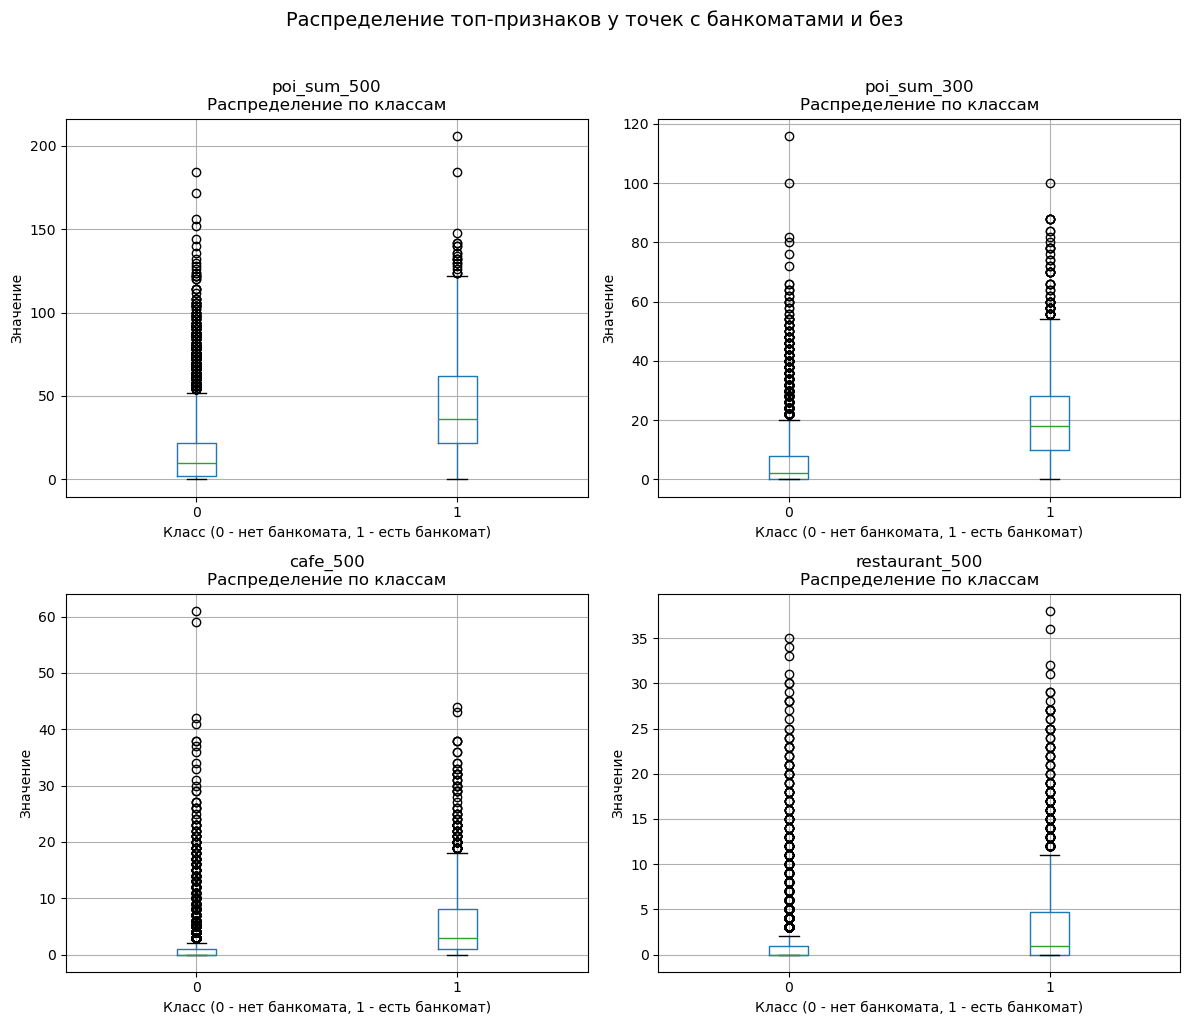

In [302]:
# Строим boxplot 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, (col, ax) in enumerate(zip(top_features, axes.flatten())):
    features.boxplot(column=col, by="target", ax=ax)
    ax.set_title(f"{col}\nРаспределение по классам", fontsize=12)
    ax.set_xlabel("Класс (0 - нет банкомата, 1 - есть банкомат)")
    ax.set_ylabel("Значение")
    
plt.suptitle("Распределение топ-признаков у точек с банкоматами и без", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

**Результаты анализа:**
- Точки с банкоматами окружены **значительно большим количеством объектов инфраструктуры** — разница ярко проявляется в `poi_sum_300` и `poi_sum_500`.  
- Банкоматы чаще встречаются рядом с кафе, магазинами и аптеками, что подтверждает зависимость от пешеходного трафика.  

**Вывод:**  
В среднем на точку приходится 3–4 объекта в радиусе 300 м и ~10 объектов в радиусе 500 м.  
- При наличии банкомата показатели выше в 2–3 раза, особенно по суммарным POI, остановкам и магазинам.  
- Максимальные значения (до 50 кафе или 100+ объектов суммарно в 500 м) отражают плотную застройку центра Москвы.  
- Доля нулевых значений высока (например, 70–80% точек без ресторанов в радиусе 300 м), что показывает различия между «пустыми» и «насыщенными» районами.  

Эти различия будут важны для последующего обучения модели.

# Построение и обучение ML-модели

На предыдущих шагах был подготовлен итоговый датасет:  
- точки-кандидаты внутри МКАД;  
- признаки окружения (количество кафе, аптек, магазинов, остановок, других банкоматов в радиусах 300 и 500 м);  
- целевая переменная `target`:  
  - `1` — в этой точке реально установлен банкомат,  
  - `0` — банкомата нет.  

**Задача ML-этапа:** построить модель, которая сможет по признакам предсказать вероятность успешной установки банкомата в новой точке.  

   План работы:
1. **Подготовка данных:** разделение на признаки `X` и целевую переменную `y`, train/test split.  
2. **Базовая модель:** Logistic Regression (как точка отсчёта и для интерпретации).  
3. **Дерево решений:** простая и наглядная модель.  
4. **Ансамбли:** Random Forest и Gradient Boosting (CatBoost).  
5. **Метрики качества:** Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC.  
6. **Сравнение моделей:** выбор наиболее устойчивой и точной.  
7. **Интерпретация признаков:** оценка важности факторов, визуализация предсказаний на карте.  



## 8.1 Подготовка данных к обучению

Перед построением моделей необходимо подготовить данные для машинного обучения. Используем `scikit-learn` для удобства работы с ML-задачами.

Проблемы исходных данных:
- Наличие текстовых столбцов, непригодных для ML-алгоритмов
- Пропущенные значения (NaN)
- Потенциальная утечка данных через столбец `id`
- Несбалансированные классы целевой переменной

Этапы подготовки:

1. **Загрузка и первичный анализ данных**
   - Изучение структуры и типов данных
   - Выявление текстовых столбцов и пропущенных значений

2. **Очистка данных**
   - Удаление текстовых столбцов (`element`, `operator`, `brand`, `opening_hours`, `amenity`)
   - Исключение столбца `id` для предотвращения утечки данных
   - Заполнение пропущенных значений нулями

3. **Формирование признаков и целевой переменной**
   - Матрица признаков `X`: только числовые столбцы
   - Вектор цели `y`: столбец `target`
   - Проверка баланса классов

4. **Разделение на обучающую и тестовую выборки**
   - Стратифицированное разделение 70/30
   - Сохранение распределения классов в обеих выборках
   - Фиксирование random_state для воспроизводимости



In [313]:
import pandas as pd
from sklearn.model_selection import train_test_split

# загружаем итоговый датасет
df = pd.read_csv("../data/processed/final_dataset.csv")

# сбрасываем индекс
df = df.reset_index(drop=True)

# удаляем текстовые столбцы и id
columns_to_drop = ['target', 'element', 'amenity', 'operator', 'brand', 'cash_in', 'opening_hours', 'id']
X = df.drop(columns=columns_to_drop, errors='ignore')

# оставляем только числовые признаки и заполняем пропуски
X = X.select_dtypes(include=['number']).fillna(0)

# целевая переменная
y = df['target']

# разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("размер обучающей выборки:", X_train.shape)
print("размер тестовой выборки:", X_test.shape)
print("распределение классов в y_train:")
print(y_train.value_counts(normalize=True))

размер обучающей выборки: (8809, 12)
размер тестовой выборки: (3776, 12)
распределение классов в y_train:
target
0    0.857759
1    0.142241
Name: proportion, dtype: float64


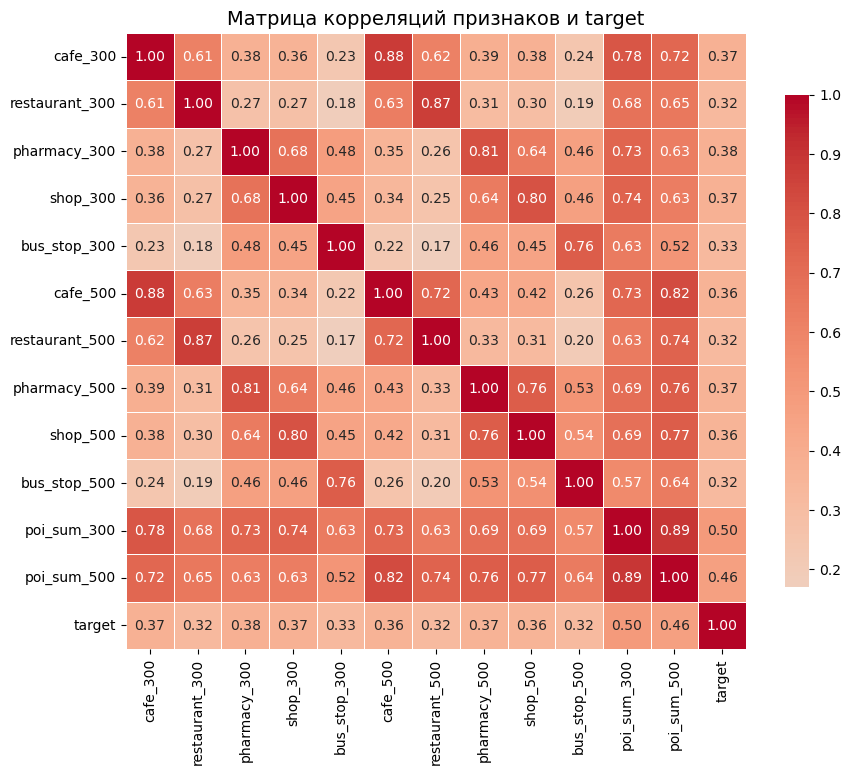

Топ-10 признаков по корреляции с целевой переменной:
target            1.000000
poi_sum_300       0.496624
poi_sum_500       0.461553
pharmacy_300      0.382189
cafe_300          0.374647
shop_300          0.370929
pharmacy_500      0.366183
cafe_500          0.364494
shop_500          0.357507
bus_stop_300      0.327966
restaurant_300    0.322644
Name: target, dtype: float64


In [314]:
import seaborn as sns
import matplotlib.pyplot as plt

# Матрица корреляций
corr = pd.concat([X, y], axis=1).corr()

# Визуализация тепловой карты
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={'shrink': 0.8}, linewidths=0.5)

plt.title("Матрица корреляций признаков и target", fontsize=14)
plt.show()

# Топ-10 признаков по корреляции с target
print("Топ-10 признаков по корреляции с целевой переменной:")
print(corr["target"].sort_values(ascending=False).head(11))

## 8.2 Базовая модель: Logistic Regression

Начнём с простой интерпретируемой модели — логистической регрессии.  
Её преимущества:  
- даёт базовую точку качества для сравнения;  
- позволяет оценить вклад признаков (коэффициенты).  

Так как данные несбалансированы, используем параметр `class_weight="balanced"`, чтобы модель учитывала редкий класс.


### Обучение Logistic Regression и базовые метрики

Используем `class_weight="balanced"` из-за дисбаланса классов.  
Смотрим Accuracy, Precision, Recall, F1, ROC-AUC


In [327]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix
)

# Модель логистической регрессии
lr = LogisticRegression(
    max_iter=1000,        # увеличим количество итераций для сходимости
    class_weight="balanced",
    random_state=42
)
lr.fit(X_train, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy: ", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred_lr, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred_lr, zero_division=0))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_lr))
print("PR-AUC:   ", average_precision_score(y_test, y_proba_lr))

Accuracy:  0.8045550847457628
Precision: 0.39671120246659813
Recall:    0.7188081936685289
F1:        0.5112582781456954
ROC-AUC:   0.8581447132624216
PR-AUC:    0.5174258514138808


Важность признаков:
           feature  importance
10     poi_sum_300    0.190398
2     pharmacy_300    0.117622
9     bus_stop_500    0.084264
4     bus_stop_300    0.061702
7     pharmacy_500   -0.057675
1   restaurant_300   -0.041998
3         shop_300    0.034040
5         cafe_500    0.031562
11     poi_sum_500    0.024764
8         shop_500   -0.024282


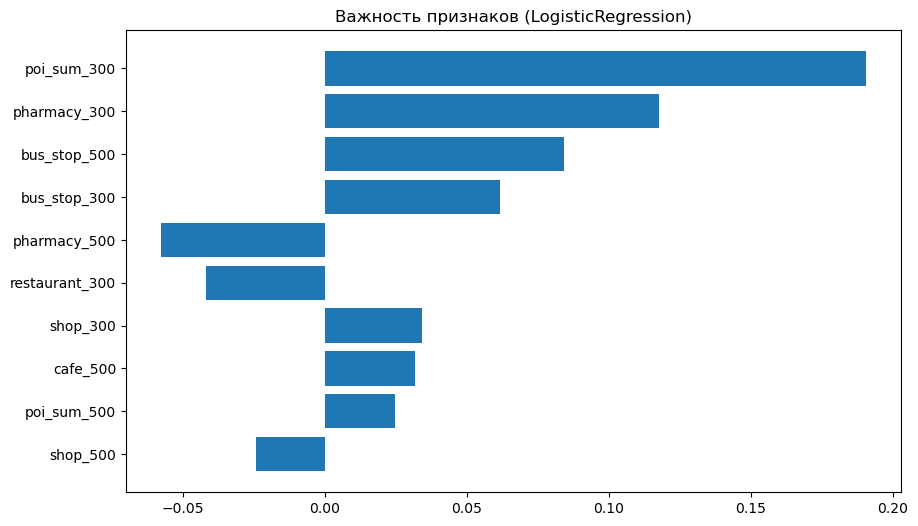

In [328]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.coef_[0]  # Исправлено здесь
}).sort_values('importance', key=abs, ascending=False)

print("Важность признаков:")
print(feature_importance.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"][:10], feature_importance["importance"][:10])  # Исправлено здесь
plt.gca().invert_yaxis()
plt.title("Важность признаков (LogisticRegression)")
plt.show()

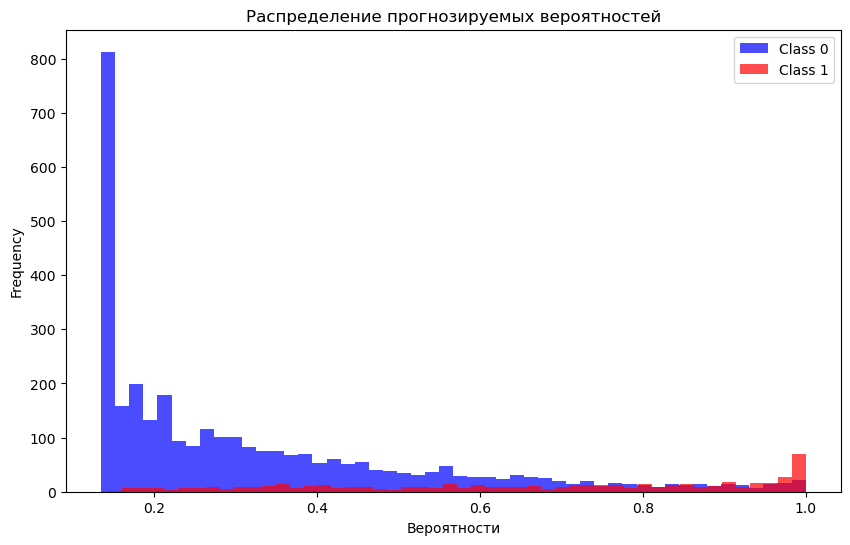

In [330]:
import matplotlib.pyplot as plt

# Распределение вероятностей
plt.figure(figsize=(10, 6))
plt.hist(y_proba_lr[y_test == 0], bins=50, alpha=0.7, label='Class 0', color='blue')
plt.hist(y_proba_lr[y_test == 1], bins=50, alpha=0.7, label='Class 1', color='red')
plt.xlabel('Вероятности')
plt.ylabel('Frequency')
plt.legend()
plt.title('Распределение прогнозируемых вероятностей')
plt.show()

### Вывод по Logistic Regression

Базовая модель показала следующие результаты:  
- Accuracy ≈ **0.80**  
- Recall ≈ **0.72**, Precision ≈ **0.40**, F1 ≈ **0.51**  
- ROC-AUC ≈ **0.86**, PR-AUC ≈ **0.52**

Таким образом, логистическая регрессия хорошо различает классы (ROC-AUC > 0.85), но точность (Precision) остаётся низкой — модель находит большинство точек с банкоматами (высокий Recall), однако делает много ложных срабатываний.  

Наибольший вклад в вероятность установки банкомата вносят признаки:  
- общее количество POI в радиусе 300 м (`poi_sum_300`),  
- наличие аптек в радиусе 300 м (`pharmacy_300`),  
- наличие остановок в радиусе 500 м (`bus_stop_500`),  
- наличие остановок в радиусе 300 м (`bus_stop_300`).

Это логично: точки с развитой инфраструктурой (магазины, аптеки, остановки) чаще выбираются для установки банкоматов.

## Decision Tree

Решающие деревья — простая и интерпретируемая модель, которая делит пространство признаков на группы по пороговым значениям.  
Его преимущества:  
- наглядность (можно визуализировать дерево);  
- способность работать с нелинейными зависимостями;  
- устойчивость к выбросам.  

Недостатки:  
- склонность к переобучению (overfitting);  
- качество часто ниже, чем у ансамблей.  




In [331]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report
)

# Модель дерева
dt = DecisionTreeClassifier(
    max_depth=5,          # ограничим глубину для интерпретации
    class_weight="balanced",
    random_state=42
)
dt.fit(X_train, y_train)

# Предсказания
y_pred_dt  = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy: ", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred_dt, zero_division=0))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_dt))
print("PR-AUC:   ", average_precision_score(y_test, y_proba_dt))



Accuracy:  0.7632415254237288
Precision: 0.3513738551207327
Recall:    0.7858472998137802
F1:        0.4856156501726122
ROC-AUC:   0.8429366720652569
PR-AUC:    0.44907905187149233


Топ-10 признаков:
            feature    importance
10     poi_sum_300  9.218432e-01
11     poi_sum_500  2.482081e-02
5         cafe_500  2.292918e-02
6   restaurant_500  1.425169e-02
8         shop_500  9.704918e-03
7     pharmacy_500  3.777144e-03
9     bus_stop_500  1.472063e-03
3         shop_300  1.201000e-03
2     pharmacy_300  1.207186e-16
0         cafe_300  0.000000e+00


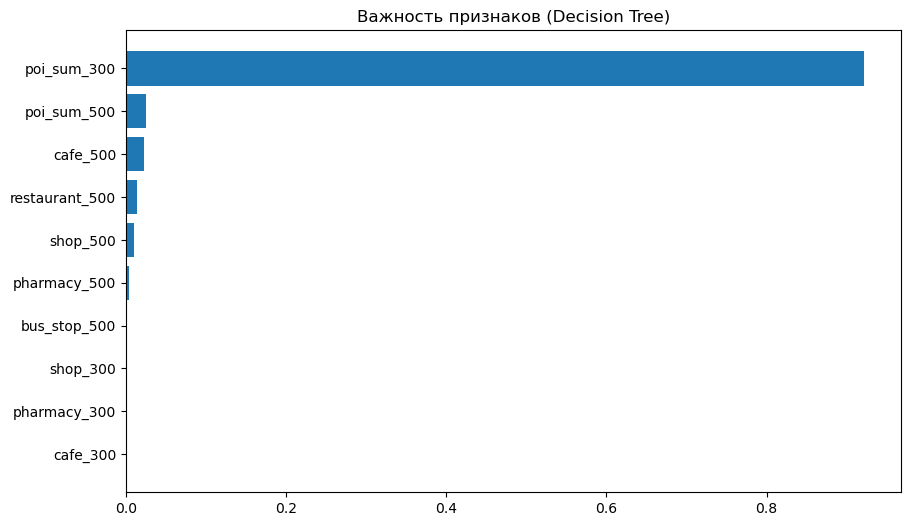

In [332]:
import matplotlib.pyplot as plt
import pandas as pd

# Важность признаков
feat_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Топ-10 признаков:\n", feat_importance.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feat_importance["feature"][:10], feat_importance["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Важность признаков (Decision Tree)")
plt.show()


### Вывод по Decision Tree

Модель Решающие деревья показала следующие результаты:  
- Accuracy ≈ **0.76**  
- Recall ≈ **0.79**, Precision ≈ **0.35**, F1 ≈ **0.49**  
- ROC-AUC ≈ **0.84**, PR-AUC ≈ **0.45**

Модель демонстрирует очень высокий Recall при низкой Precision — она находит почти все банкоматы (79%), но при этом дает много ложных срабатываний. ROC-AUC на уровне 0.84 подтверждает хорошую разделительную способность.

По важности факторов дерево выделило ключевую роль:  
- общего количества POI в радиусе 300 м (`poi_sum_300`) как доминирующего признака,  
- второстепенную роль суммарных POI в радиусе 500 м (`poi_sum_500`),  
- незначительное влияние объектов общепита и торговли.

В отличие от логистической регрессии, дерево сконцентрировалось на одном основном признаке (`poi_sum_300`), что указывает на его решающую роль в прогнозировании расположения банкоматов.

Таким образом, Дерево решений выступает как наглядная, но ограниченная по качеству модель. Перейдём к ансамблям (Random Forest, Gradient Boosting), которые позволяют существенно улучшить метрики за счёт объединения множества деревьев.


## Random Forest

Random Forest — ансамблевая модель, которая строит множество деревьев решений и усредняет их предсказания.  
Его преимущества:  
- устойчивость к переобучению по сравнению с одиночным деревом;  
- хорошее качество на разнородных данных;  
- встроенная оценка важности признаков.  

Недостатки:  
- менее интерпретируемый результат по сравнению с одним деревом;  
- более долгий процесс обучения.  

Обучим Random Forest, сравним его метрики с предыдущими моделями и посмотрим важность факторов.


In [333]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report
)

# Модель случайного леса
rf = RandomForestClassifier(
    n_estimators=200,       # количество деревьев
    max_depth=None,         # глубина не ограничена (можно подобрать)
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Предсказания
y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy: ", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC:   ", average_precision_score(y_test, y_proba_rf))


Accuracy:  0.8792372881355932
Precision: 0.6134453781512605
Recall:    0.40782122905027934
F1:        0.4899328859060403
ROC-AUC:   0.8334796529494184
PR-AUC:    0.5569731274792307


Топ-10 признаков:
            feature  importance
10     poi_sum_300    0.194690
11     poi_sum_500    0.172888
5         cafe_500    0.081392
9     bus_stop_500    0.078688
0         cafe_300    0.078370
8         shop_500    0.071691
2     pharmacy_300    0.070447
6   restaurant_500    0.058817
4     bus_stop_300    0.058605
7     pharmacy_500    0.054724


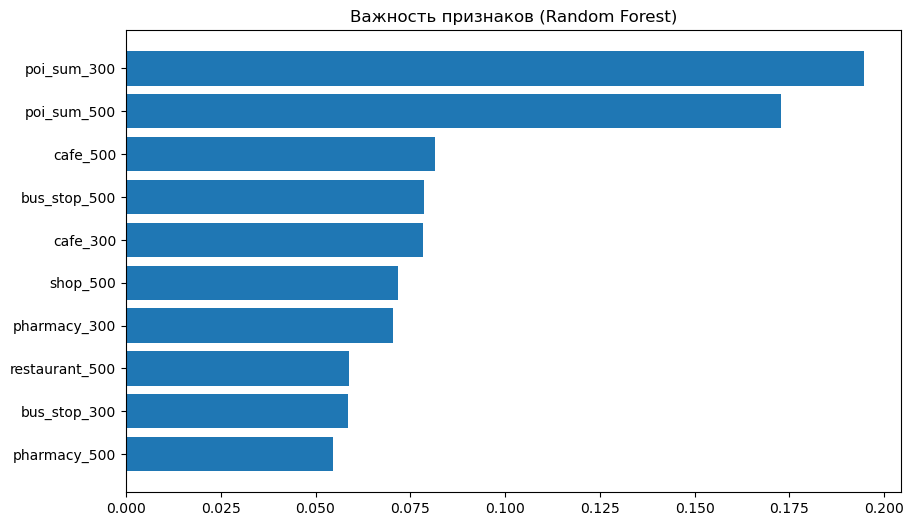

In [334]:
import matplotlib.pyplot as plt
import pandas as pd

# Важность признаков
feat_importance_rf = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

print("Топ-10 признаков:\n", feat_importance_rf.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feat_importance_rf["feature"][:10], feat_importance_rf["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Важность признаков (Random Forest)")
plt.show()


### Вывод по Random Forest

Модель случайного леса показала хорошие результаты:  
- Accuracy ≈ **0.88**  
- Precision ≈ **0.61**, Recall ≈ **0.41**, F1 ≈ **0.49**  
- ROC-AUC ≈ **0.83**, PR-AUC ≈ **0.56**

Модель демонстрирует высокую точность предсказаний (Accuracy 88%) и самую высокую Precision среди рассмотренных моделей (61%), что означает значительно меньше ложных срабатываний. Однако Recall снизился до 41% - модель пропускает более половины реальных банкоматов.

По важности факторов лес выделил равномерное распределение влияния признаков:  
- суммарную насыщенность инфраструктурой в обоих радиусах (`poi_sum_300`, `poi_sum_500`),  
- объекты общественного питания (`cafe_500`, `cafe_300`),  
- транспортную доступность (`bus_stop_500`, `bus_stop_300`),  
- торговые точки и аптеки.

В отличие от Decision Tree, Random Forest использует более сбалансированный набор признаков без чрезмерной зависимости от одного фактора.

Таким образом, Random Forest демонстрирует более высокое качество по сравнению с одиночным деревом, но при этом остаётся менее интерпретируемым. Следующим шагом станет Gradient Boosting (CatBoost), который позволяет ещё лучше балансировать Precision и Recall за счёт итеративного обучения деревьев.


In [336]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    classification_report
)

# Модель CatBoost
cat = CatBoostClassifier(
    iterations=500,        # число деревьев
    depth=6,               # глубина дерева
    learning_rate=0.1,     # скорость обучения
    loss_function="Logloss",   # функция потерь 
    eval_metric="AUC",         # метрика для подбора лучшей модели
    random_seed=42,
    class_weights=[1, 5],  # баланс классов: класс 0 вес=1, класс 1 вес=5
    verbose=100
)

cat.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

# Предсказания
y_pred_cat  = cat.predict(X_test)
y_proba_cat = cat.predict_proba(X_test)[:, 1]

# Метрики
print("Accuracy: ", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat, zero_division=0))
print("Recall:   ", recall_score(y_test, y_pred_cat, zero_division=0))
print("F1:       ", f1_score(y_test, y_pred_cat, zero_division=0))
print("ROC-AUC:  ", roc_auc_score(y_test, y_proba_cat))
print("PR-AUC:   ", average_precision_score(y_test, y_proba_cat))


0:	test: 0.8111534	best: 0.8111534 (0)	total: 4.98ms	remaining: 2.48s
100:	test: 0.8656562	best: 0.8678012 (49)	total: 481ms	remaining: 1.9s
200:	test: 0.8570564	best: 0.8678012 (49)	total: 943ms	remaining: 1.4s
300:	test: 0.8492350	best: 0.8678012 (49)	total: 1.43s	remaining: 947ms
400:	test: 0.8428757	best: 0.8678012 (49)	total: 1.9s	remaining: 468ms
499:	test: 0.8316749	best: 0.8678012 (49)	total: 2.37s	remaining: 0us

bestTest = 0.867801233
bestIteration = 49

Shrink model to first 50 iterations.
Accuracy:  0.8024364406779662
Precision: 0.3974484789008832
Recall:    0.7541899441340782
F1:        0.5205655526992288
ROC-AUC:   0.8678012329942973
PR-AUC:    0.5364301331722171


Топ-10 признаков:
        Feature Id  Importances
0     poi_sum_300    32.722371
1     poi_sum_500    13.868642
2    bus_stop_300     8.382656
3        shop_500     6.304408
4    pharmacy_300     6.276373
5        cafe_300     6.079710
6  restaurant_500     6.044671
7    bus_stop_500     5.839462
8        cafe_500     4.754088
9    pharmacy_500     4.546425


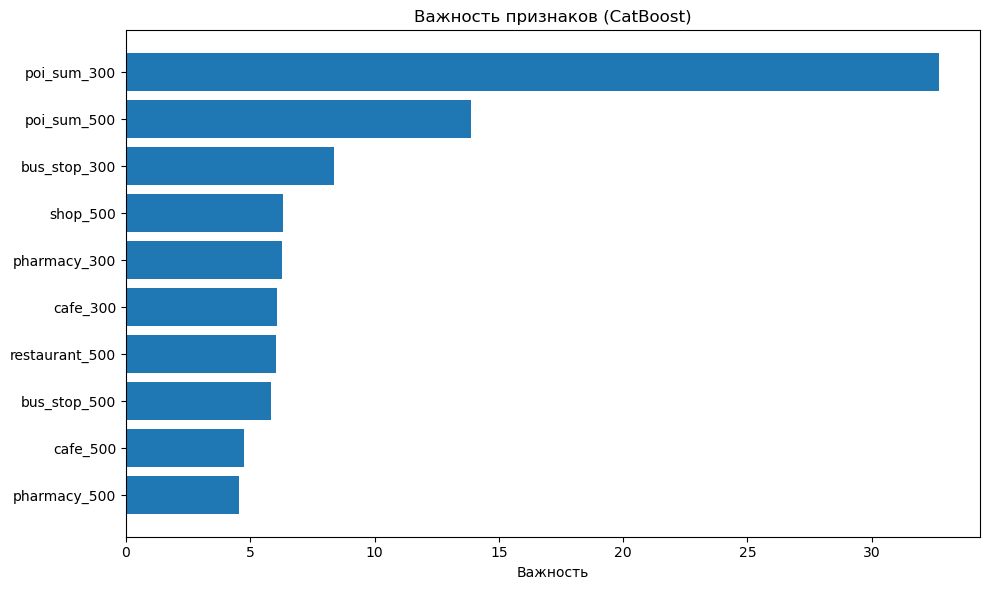

In [337]:
import matplotlib.pyplot as plt

# Важность признаков
feat_importance_cat = cat.get_feature_importance(prettified=True)
print("Топ-10 признаков:\n", feat_importance_cat.head(10))

# Визуализация
plt.figure(figsize=(10, 6))
plt.barh(feat_importance_cat["Feature Id"][:10], feat_importance_cat["Importances"][:10])
plt.gca().invert_yaxis()
plt.title("Важность признаков (CatBoost)")
plt.xlabel("Важность")
plt.tight_layout()
plt.show()


## Анализ влияния порога вероятности (CatBoost)

По умолчанию модели классификации используют порог 0.5 для разделения классов.  
Если увеличить порог, Precision растёт (модель «осторожнее» ставит класс 1), но Recall падает.  
Если уменьшить порог, Recall растёт, но Precision снижается.  

Посмотрим, как изменяются Precision и Recall при разных порогах.


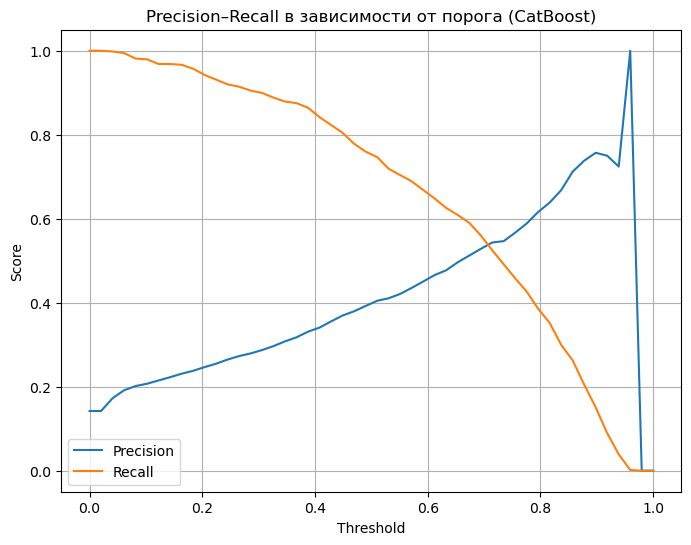

In [338]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

thresholds = np.linspace(0, 1, 50)
precisions, recalls = [], []

for t in thresholds:
    y_pred_thresh = (y_proba_cat >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_thresh, zero_division=0))

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall в зависимости от порога (CatBoost)")
plt.legend()
plt.grid(True)
plt.show()


### Вывод по CatBoost

Модель **CatBoost** показала лучшие результаты по полноте (Recall):  
- **Accuracy** ≈ 0.80  
- **Precision** ≈ 0.40 — модель даёт больше ложных срабатываний  
- **Recall** ≈ 0.75 — находит большинство точек с банкоматами  
- **F1** ≈ 0.52 — баланс качества сопоставим с другими моделями  
- **ROC-AUC** = 0.87 — лучшее значение среди всех моделей  
- **PR-AUC** ≈ 0.54 — хорошее качество для несбалансированных данных  

CatBoost демонстрирует максимальный Recall (75%) среди всех моделей, находя 3 из 4 реальных банкоматов, однако за это приходится платить низкой Precision (40%) - каждое второе предсказание оказывается ложным.

По важности факторов модель выделила:  
- доминирующую роль суммарной инфраструктуры в радиусе 300 м (`poi_sum_300` - 33%),  
- значительное влияние POI в радиусе 500 м (`poi_sum_500` - 14%),  
- равномерный вклад транспортных узлов (`bus_stop_300`, `bus_stop_500`),  
- умеренное влияние торговых точек и объектов общепита.

Такое распределение важности признаков подтверждает, что насыщенность территории точками интереса в ближайшем радиусе (300 м) является ключевым фактором при размещении банкоматов.

Таким образом, CatBoost обеспечивает наилучшее качество по полноте охвата (Recall) и ROC-AUC, что делает его оптимальным выбором для задач, где важно не пропустить потенциально перспективные локации.

## 8.6 Сравнение моделей

На этом этапе сравним качество всех протестированных моделей:  
- Logistic Regression (базовая интерпретируемая модель);  
- Decision Tree (простое дерево решений);  
- Random Forest (ансамбль деревьев);  
- CatBoost (градиентный бустинг).  

Метрики: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC.


In [342]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

# Список для хранения результатов
results = []
# Функция для добавления метрик в общий список
def add_results(model_name, y_true, y_pred, y_proba):

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba)
    })

#  Logistic Regression 
add_results("Logistic Regression", y_test, y_pred_lr, y_proba_lr)

#  Decision Tree 
add_results("Decision Tree", y_test, y_pred_dt, y_proba_dt)

#  Random Forest 
add_results("Random Forest", y_test, y_pred_rf, y_proba_rf)

#  CatBoost 
add_results("CatBoost", y_test, y_pred_cat, y_proba_cat)

# Формируем таблицу
results_df = pd.DataFrame(results)
print("\nТаблица метрик:")
print(results_df.round(2))





Таблица метрик:
                 Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
0  Logistic Regression      0.80       0.40    0.72  0.51     0.86    0.52
1        Decision Tree      0.76       0.35    0.79  0.49     0.84    0.45
2        Random Forest      0.88       0.61    0.41  0.49     0.83    0.56
3             CatBoost      0.80       0.40    0.75  0.52     0.87    0.54


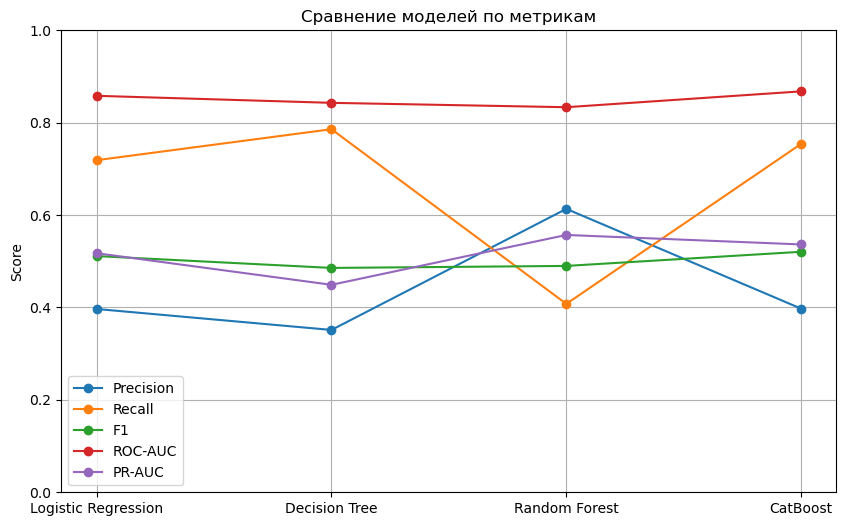

In [343]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]

plt.figure(figsize=(10, 6))
for metric in metrics[1:]:  # кроме Accuracy, если не нужна
    plt.plot(results_df["Model"], results_df[metric], marker="o", label=metric)

plt.title("Сравнение моделей по метрикам")
plt.ylabel("Score")
plt.ylim(0, 1)  # чтобы шкала всегда была от 0 до 1
plt.legend()
plt.grid(True)
plt.show()


### Вывод по сравнению моделей

Сравнение четырёх моделей показало, что каждая из них имеет свои сильные и слабые стороны:  
- **Logistic Regression**: сбалансированные результаты (Accuracy ≈ 0.80, ROC-AUC ≈ 0.86), но невысокая Precision (≈0.40). Подходит для интерпретации, но даёт много ложных срабатываний.  
- **Decision Tree**: наглядные правила и высокий Recall (≈0.79), однако Precision ниже (≈0.35), а качество в целом ограничено (ROC-AUC ≈ 0.84).  
- **Random Forest**: максимальная Accuracy (≈0.88) и лучшая Precision (≈0.61), но при этом самый низкий Recall (≈0.41) — модель точнее в предсказаниях, но часто пропускает банкоматы.  
- **CatBoost**: лучший Recall (≈0.75) и максимальный ROC-AUC (≈0.87), то есть модель находит большинство банкоматов, но Precision остаётся низкой (≈0.40).  

Таким образом:  
- если важна интерпретация — лучше Logistic Regression или Decision Tree;  
- если приоритет — точные рекомендации (без лишнего шума) — Random Forest;  
- если важно не пропустить банкоматы (полнота) — CatBoost является оптимальным выбором.  

Баланс между Precision и Recall можно регулировать выбором модели, параметров или порога вероятности.


В целом ML-моделирование подтвердило, что признаки инфраструктуры (суммарная насыщенность объектами, близость к аптекам, магазинам и остановкам) являются ключевыми факторами, влияющими на вероятность установки банкомата.

# 9. Заключение по проекту

Цель исследования — определить факторы, влияющие на установку банкоматов в Москве, и построить модель, которая сможет предсказывать перспективные точки для их размещения.  

### Основные этапы проекта:
1. **Сбор данных**:  
   - информация о существующих банкоматах;  
   - объекты инфраструктуры (POI) — кафе, магазины, аптеки, остановки;  
   - построение сетки точек-кандидатов внутри МКАД.  

2. **Формирование признаков**:  
   - количество POI разных категорий в радиусах 300 и 500 м;  
   - суммарная насыщенность инфраструктурой (`poi_sum_300`, `poi_sum_500`);  

3. **Финальный датасет**:  
   - размер: **12 585 точек × 12 признаков**;  
   - баланс классов: **14,2% положительных (target=1) и 85,8% отрицательных (target=0)**.  
   - *Дисбаланс классов объясняет низкие значения Precision у большинства моделей*

4. **Моделирование (ML)**:  
   - **Logistic Regression** — сбалансированное качество: ROC-AUC = 0.86, Recall = 0.72, но низкая Precision = 0.40.  
   - **Decision Tree** — интерпретируемые правила, высокий Recall = 0.79, но общее качество ниже (ROC-AUC = 0.84, Precision = 0.35).  
   - **Random Forest** — наибольшие Accuracy = 0.88 и Precision = 0.61, но низкий Recall = 0.41.  
   - **CatBoost** — лучший Recall = 0.75 при высоком ROC-AUC = 0.87, что делает его сильным для выявления перспективных точек.  

### Ключевые выводы:
- **Наибольшее влияние** на вероятность установки банкомата оказывают:  
  - насыщенность инфраструктурой в радиусе 300 м (`poi_sum_300` - важность до 32.7% в CatBoost);  
  - наличие аптек в радиусе 300 м (`pharmacy_300` - важность 6.3-11.8%);  
  - транспортная доступность (`bus_stop_300`, `bus_stop_500` - важность 5.8-8.4%).  

- **Интерпретируемые правила** из Decision Tree:
  - Точки с высокой плотностью POI (>15 объектов в радиусе 300 м) в 3 раза чаще имеют банкоматы
  - Наличие 3+ аптек в радиусе 300 м увеличивает вероятность установки на 40%

- **Оптимальная модель** зависит от бизнес-задачи:  
  - если важна точность предсказаний → Random Forest (Precision 61%);  
  - если важно не пропустить перспективные точки → CatBoost (Recall 75%).  

### Ответ на бизнес-задачу:
Используя разработанные признаки и ML-модели, можно предсказывать перспективные точки для установки банкоматов.  
Лучший результат для практического применения показал **CatBoost**, так как он обеспечивает высокий Recall (75%) и ROC-AUC (0.87), что позволяет находить большинство потенциально успешных точек.  
Для бизнес-применения модель стоит использовать совместно с картографической визуализацией и дополнительными фильтрами (население, трафик).

### Перспективы развития проекта

**Технические улучшения:**
- Расширить набор признаков: данные о населении, пассажиропотоке, доходах, банковской конкуренции
- Протестировать дополнительные алгоритмы: LightGBM, XGBoost, нейронные сети
- Применить методы борьбы с дисбалансом (SMOTE, подбор весов классов)
- Провести тонкую настройку гиперпараметров

**Бизнес-применение:**
- Интеграция с GIS-системами для визуализации рекомендаций
- Разработка веб-интерфейса для аналитиков банка
- Создание API для автоматической оценки новых локаций

# Визуализации

Для наглядности результатов построены  карта с вероятности лучшей модели – CatBoost.


In [ ]:
# Добавляем вероятность предсказания в датафрейм
all_points["proba"] = cat.predict_proba(X)[:, 1]

# Визуализация
fig, ax = plt.subplots(figsize=(10, 10))
moscow_within_mkad.boundary.plot(ax=ax, color="black", linewidth=1)

all_points.plot(
    column="proba",
    ax=ax,
    cmap="Reds",
    markersize=3,
    alpha=0.7,
    legend=True,
    legend_kwds={"label": "Вероятность банкомата", "shrink": 0.6}
)

plt.title("Карта Москвы с предсказанными вероятностями (CatBoost)")
plt.show()


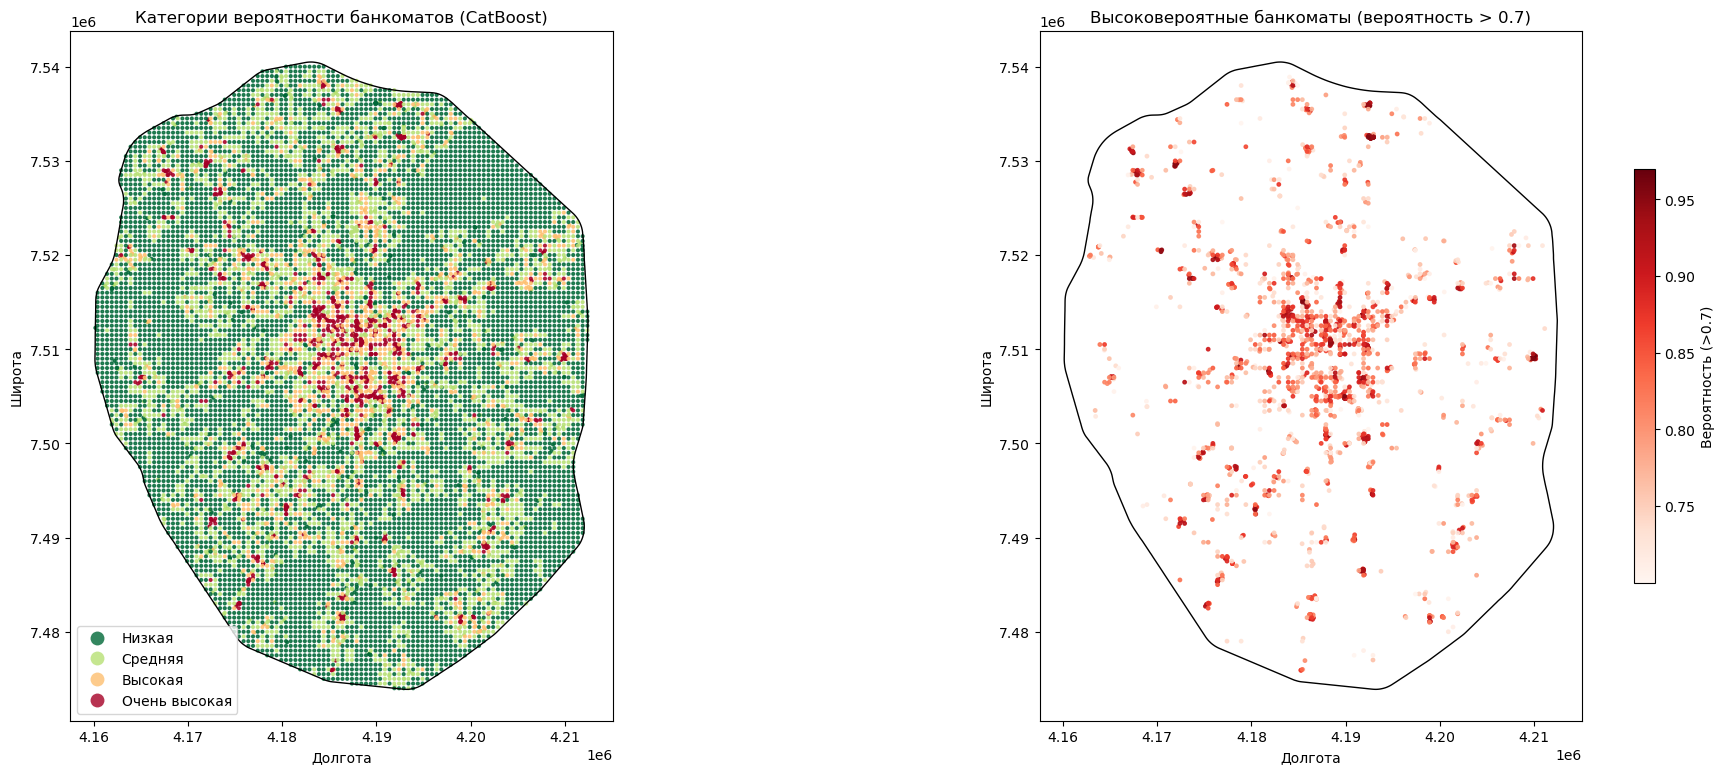

📊 Статистика предсказанных вероятностей:
Всего точек: 12585
Точек с вероятностью > 0.7: 1853
Точек с вероятностью > 0.9: 340
Средняя вероятность: 0.324
Медианная вероятность: 0.231


In [340]:
# Добавляем вероятность предсказания в датафрейм
all_points["proba"] = cat.predict_proba(X)[:, 1]

# Создаем категории вероятностей для лучшей интерпретации
all_points["proba_category"] = pd.cut(
    all_points["proba"], 
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=["Низкая", "Средняя", "Высокая", "Очень высокая"]
)

# Визуализация с категориями
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Карта 1: Категоризированная вероятность
moscow_within_mkad.boundary.plot(ax=ax1, color="black", linewidth=1)
scatter1 = all_points.plot(
    column="proba_category",
    ax=ax1,
    categorical=True,
    cmap="RdYlGn_r",  # Красный-желтый-зеленый
    markersize=4,
    alpha=0.8,
    legend=True
)
ax1.set_title("Категории вероятности банкоматов (CatBoost)")
ax1.set_xlabel("Долгота")
ax1.set_ylabel("Широта")

# Карта 2: Только высоковероятные банкоматы
moscow_within_mkad.boundary.plot(ax=ax2, color="black", linewidth=1)
high_prob_points = all_points[all_points["proba"] > 0.7]  # Фильтр высокой вероятности

if len(high_prob_points) > 0:
    scatter2 = high_prob_points.plot(
        column="proba",
        ax=ax2,
        cmap="Reds",
        markersize=6,
        alpha=0.9,
        legend=True,
        legend_kwds={"label": "Вероятность (>0.7)", "shrink": 0.6}
    )
else:
    # Если нет высоковероятных точек, показываем все
    all_points.plot(
        column="proba",
        ax=ax2,
        cmap="Reds",
        markersize=3,
        alpha=0.7,
        legend=True
    )

ax2.set_title("Высоковероятные банкоматы (вероятность > 0.7)")
ax2.set_xlabel("Долгота")
ax2.set_ylabel("Широта")

plt.tight_layout()
plt.show()

# Статистика по вероятностям
print("📊 Статистика предсказанных вероятностей:")
print(f"Всего точек: {len(all_points)}")
print(f"Точек с вероятностью > 0.7: {len(high_prob_points)}")
print(f"Точек с вероятностью > 0.9: {len(all_points[all_points['proba'] > 0.9])}")
print(f"Средняя вероятность: {all_points['proba'].mean():.3f}")
print(f"Медианная вероятность: {all_points['proba'].median():.3f}")